In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import os
import json

In [2]:
train_pth = os.path.join(os.getcwd(), "DatiumTrain.rpt")
train_df = pd.read_table(train_pth, delimiter = "\t")

/var/folders/zk/jyn4pz795tl33j_m94s1rzcr0000gn/T/ipykernel_76017/2577385021.py:2: DtypeWarning: Columns (27,94) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_table(train_pth, delimiter = "\t")


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50704 entries, 0 to 50703
Columns: 130 entries, Make to Sold_Amount
dtypes: float64(65), int64(6), object(59)
memory usage: 50.3+ MB


In [4]:
pd.set_option('display.max_columns', 130)

Some of these columns are completely empty!

In [5]:
train_df.describe()

,YearGroup,MonthGroup,SequenceNum,GearNum,DoorNum,EngineSize,Cylinders,FuelCapacity,GrossCombinationMAss,GrossVehicleMass,WheelBase,Height,Length,Width,KerbWeight,TareMass,PayLoad,Power,PowerRPMFrom,PowerRPMTo,Torque,TorqueRPMFrom,TorqueRPMTo,RonRating,SeatCapacity,ValvesCylinder,Acceleration,TowingBrakes,TowingNoBrakes,WarrantyYears,WarrantyKM,FirstServiceKM,FirstServiceMonths,RegServiceMonths,AltEngAmpHours,AltEngVolts,AltEngPower,AltEngPowerFrom,AltEngPowerTo,AltEngTorque,AltEngTorqueFrom,AltEngTorqueTo,NormalChargeMins,QuickChargeMins,NormalChargeVoltage,QuickChargeVoltage,KMRangeElectricEng,TopSpeedElectricEng,GreenhouseRating,AirpollutionRating,OverallGreenStarRating,CO2Combined,CO2Urban,CO2ExtraUrban,FuelUrban,FuelExtraurban,FuelCombined,AncapRating,AverageKM,GoodKM,AvgWholesale,AvgRetail,GoodWholesale,GoodRetail,TradeMin,TradeMax,PrivateMax,NewPrice,Age_Comp_Months,KM,Sold_Amount
count,50704.000000,50704.000000,50704.000000,50703.000000,50704.000000,50704.000000,50704.000000,49892.000000,24524.000000,30463.000000,50561.000000,49985.000000,50045.000000,50047.000000,49170.000000,40153.000000,25615.000000,50592.000000,209.000000,50566.000000,50431.000000,4699.000000,50396.000000,39737.000000,50667.000000,50194.000000,15130.000000,47760.000000,45504.000000,48090.000000,47739.000000,30732.000000,27891.000000,30746.000000,6.000000,836.000000,836.000000,156.000000,237.000000,785.000000,0.0,164.00000,0.0,0.0,0.0,0.0,2.0,2.0,24644.000000,24630.000000,24821.000000,33730.000000,12112.000000,12110.000000,29394.000000,28241.000000,46346.000000,25965.000000,50703.000000,50703.000000,37594.000000,45973.000000,43951.000000,50703.000000,37594.000000,37594.000000,50703.000000,50703.000000,50659.000000,5.070200e+04,50700.000000
mean,2005.177777,1.480396,9.632869,4.615447,4.124467,3000.569580,5.061731,71.905035,4237.271489,2353.787874,2795.959890,1575.180834,4769.513758,1809.761105,1583.991499,1553.754937,778.293031,136.335146,3887.081340,5249.226753,286.095953,1900.404341,3454.733352,91.228301,4.888902,3.518827,9.574197,1803.142274,629.580916,3.101851,92852.096839,6691.819602,5.245420,9.609640,6.266667,542.083254,82.557895,1193.333333,5268.270042,280.834395,NaN,1193.04878,NaN,NaN,NaN,NaN,37.0,120.0,5.701530,5.819610,3.323819,232.896294,283.967801,171.276879,11.587654,7.170908,9.476818,4.260312,306.617163,188.857168,7518.701123,8928.714680,8223.517099,10038.255133,6556.740437,8468.244933,9018.105438,36726.014555,45.775223,8.495406e+04,16401.722226
std,5.302207,2.997782,11.171761,0.956656,0.868757,931.057061,1.123823,22.131647,1090.250085,506.228417,196.377199,180.821663,316.896285,78.646715,282.673958,276.970755,311.324374,41.839118,799.895184,875.834698,88.995227,752.174969,850.284910,0.991823,1.280512,0.848572,1.843429,632.023565,139.894331,0.490317,32103.990718,4848.229330,3.470849,2.818618,0.361478,165.663202,30.820288,41.228448,5513.802631,72.269200,NaN,67.03518,NaN,NaN,NaN,NaN,0.0,0.0,1.128458,1.824878,0.724334,49.219886,63.595995,34.881419,2.642395,1.392198,2.102242,0.654834,139.121984,88.032477,7092.971211,7873.691056,7556.364122,8454.463138,6474.531721,7049.352627,7709.541957,15522.567237,32.153830,7.283732e+04,10312.029249
min,1968.000000,0.000000,0.000000,1.000000,2.000000,659.000000,2.000000,32.000000,1450.000000,970.000000,2.000000,1070.000000,2500.000000,1370.000000,640.000000,720.000000,260.000000,32.000000,3000.000000,2600.000000,67.000000,1000.000000,1200.000000,91.000000,2.000000,2.000000,3.900000,200.000000,100.000000,1.000000,-1.000000,1000.000000,1.000000,3.000000,5.800000,100.000000,10.000000,940.000000,1500.000000,78.000000,NaN,940.00000,NaN,NaN,NaN,NaN,37.0,120.0,1.500000,0.500000,0.500000,89.000000,86.000000,86.000000,3.700000,3.700000,3.900000,1.000000,35.000000,20.000000,600.000000,1500.000000,800.000000,750.000000,300.000000,1800.000000,700.000000,5157.000000,0.000000,0.000000e+00,0.000000
25%,2001.000000,0.000000,1.000000,4.000000,4.000000,2359.000000,4.000000,63.000000,3310.000000,1990.000000,2670.000000,1450

Some of these columns only have a single value, or represent the same thing

In [6]:
train_df.describe(include="object")

,Make,Model,MakeCode,FamilyCode,Description,CurrentRelease,ImportFlag,LimitedEdition,Series,SeriesModelYear,BadgeDescription,BadgeSecondaryDescription,BodyStyleDescription,BodyConfigDescription,WheelBaseConfig,Roofline,ExtraIdentification,DriveDescription,DriveCode,GearTypeDescription,GearLocationDescription,EngineDescription,FuelTypeDescription,InductionDescription,OptionCategory,CamDescription,EngineTypeDescription,FuelDeliveryDescription,MethodOfDeliveryDescription,VIN,ModelCode,BuildCountryOriginDescription,EngineCycleDescription,EngineConfigurationDescription,EngineLocation,EngineNum,FrontTyreSize,RearTyreSize,FrontRimDesc,RearRimDesc,WarrantyCustAssist,FreeScheduledService,AltEngEngineType,AltEngBatteryType,AltEngCurrentType,AltEngChargingMethod,AltEngDrive,ElectricEngineLocation,EmissionStandard,MaxEthanolBlend,VFactsClass,VFactsSegment,VFactsPrice,IsPPlateApproved,Colour,Branch,SaleCategory,Sold_Date,Compliance_Date
count,50704,50704,50704,50704,50704,50704,50704,50704,49853,15540,44099,2433,50704,8683,1799,520,3257,50704,50704,50704,50704,50704,50704,50704,50704,50486,50704,50704,50682,50126,40274,50703,50703,48844,50691,49900,49800,49800,49978,49978,22755,96,838,838,838,838,835,26,8949,2097,50276,50276,40323,50703,50660,50703,50703,50703,50659
unique,52,582,52,581,8568,1,1,2,1034,46,648,186,16,3,4,3,133,7,7,8,7,111,6,7,6,10,3,7,3,3978,3386,31,2,10,3,1521,295,313,69,82,59,7,2,2,2,3,3,2,5,2,4,13,17,2,905,18,6,4747,404
top,Toyota,Commodore,TOYO,COMMODO,ACV40R Altise Sedan 4dr Auto 5sp 2.4i,F,L,F,VE,MY10,Executive,Hi-Rider,Sedan,Dual Cab,Long Wheelbase,High Roof,LPG Only,Rear Wheel Drive,RWD,Automatic,Floor,4.0,Petrol - Unleaded ULP,Aspirated,PASS,DOHC with VVT,Piston,Multi-Point Injection,Electronic Sequential,6FPAAAJGSW3M#####,ACV40R-DEADKQ,AUSTRALIA,4 Stroke,In-line,Front,VA-######,205/65 R15,205/65 R15,15x6.0,15x6.0,roadside assist,"3 yr, 100,000 km",Permanent Magnet,Nickel Metal Hydride,AC,Engine,Wheels Front,Front,Euro 4,E10,Passenger,Large,< $70K,T,White,Belmore (NSW),Auction,2015-07-01 00:00:00.000,06/2010
freq,15720,6827,15720,6827,707,50704,50704,49893,1713,3605,3302,210,20594,4182,734,239,846,21863,21863,22783,47630,6785,38405,42186,31771,22571,49847,41197,38453,1474,1091,23478,50685,31621,50650,2078,7964,7958,11270,11076,8211,61,824,810,772,763,802,18,5458,1368,31672,20267,19376,48580,15738,15188,38804,62,431


Let's drop columns first, there are just too many of em.

I am dropping the columns based on the following criteria:
1. More than 90% missing values
2. Single value in the columns (CurrentRelease, ImportFlag)
3. Identifiers (SequenceNum, VIN, ModelCode, EngineNum)
4. Duplicate columns (Make, Model, DriveDescription can be replaced with MakeCode, FamilyCode, DriveCode respectively)
5. VFactsClass, which has missing values, can potentially be replaced with OptionCategory (to further explore)


In [7]:
train_df.dropna(axis=1, thresh= int(0.9 * len(train_df)), inplace = True)

In [8]:
cols_to_drop = ["CurrentRelease","ImportFlag","SequenceNum","VIN","ModelCode","EngineNum","Make","Model","DriveDescription"]
cols_to_drop = [x for x in cols_to_drop if x in train_df.columns]
cols_to_drop

['CurrentRelease',
 'ImportFlag',
 'SequenceNum',
 'VIN',
 'EngineNum',
 'Make',
 'Model',
 'DriveDescription']

In [9]:
train_df.drop(columns=cols_to_drop, inplace = True)

After initial cleaning, we have halved the number of features we have (from 130 to 64)

In [10]:
train_df.shape

(50704, 64)

We still have missing features here and there, and have yet to go over the details of all features in the dataset (although is that something we want to do?)

My take is to think of what features would be important to developing this model? What would a customer look for when buying a car? What would make them want to pay more or less for it? I believe it can come down to the following features (if available within the data):

1. Brand: Customers may have a preference for a brand or be a regular buyer of a specific brand of cars like Toyotas for their affordability and reliability.
2. Model: This **may** matter, although to a lesser degree, as most likely a customer would preview a few model of cars before deciding on which one best suits them.
3. Type: The customer would be looking for the type of car that suits their preferences and needs (SUV, Wagon, Sedan, Hatchback, some kind of people mover)
4. Electric/Gas: There might be a preference for whether the vehicle is considered sustainable. However, I noticed that most of the columns with largely missing values fell into some kind of electric vehicle category.
5. Power: How powerful is the car that it is worth paying that kind of price for it.
6. Size: How big the car is (although this may already be described by the **Type*  to some extent)
7. Age: How old is the car? I assume that the 'classic' cars would be considered more expensive, although we will have to look into the data more to figure that out.
8. Mileage: This is basically a wear and tear indicator for the customer.
9. Color: Customers would have a preference for a color of car they want to use
10. Sale Type: I believe this might matter, as the way cars are sold is very different (like between an auction and a private car sale)
11. Branch: This may matter, but we have to see

In [11]:
train_df.describe(include="object")

,MakeCode,FamilyCode,Description,LimitedEdition,Series,BodyStyleDescription,DriveCode,GearTypeDescription,GearLocationDescription,EngineDescription,FuelTypeDescription,InductionDescription,OptionCategory,CamDescription,EngineTypeDescription,FuelDeliveryDescription,MethodOfDeliveryDescription,BuildCountryOriginDescription,EngineCycleDescription,EngineConfigurationDescription,EngineLocation,FrontTyreSize,RearTyreSize,FrontRimDesc,RearRimDesc,VFactsClass,VFactsSegment,IsPPlateApproved,Colour,Branch,SaleCategory,Sold_Date,Compliance_Date
count,50704,50704,50704,50704,49853,50704,50704,50704,50704,50704,50704,50704,50704,50486,50704,50704,50682,50703,50703,48844,50691,49800,49800,49978,49978,50276,50276,50703,50660,50703,50703,50703,50659
unique,52,581,8568,2,1034,16,7,8,7,111,6,7,6,10,3,7,3,31,2,10,3,295,313,69,82,4,13,2,905,18,6,4747,404
top,TOYO,COMMODO,ACV40R Altise Sedan 4dr Auto 5sp 2.4i,F,VE,Sedan,RWD,Automatic,Floor,4.0,Petrol - Unleaded ULP,Aspirated,PASS,DOHC with VVT,Piston,Multi-Point Injection,Electronic Sequential,AUSTRALIA,4 Stroke,In-line,Front,205/65 R15,205/65 R15,15x6.0,15x6.0,Passenger,Large,T,White,Belmore (NSW),Auction,2015-07-01 00:00:00.000,06/2010
freq,15720,6827,707,49893,1713,20594,21863,22783,47630,6785,38405,42186,31771,22571,49847,41197,38453,23478,50685,31621,50650,7964,7958,11270,11076,31672,20267,48580,15738,15188,38804,62,431


In [12]:
train_df.describe()

,YearGroup,MonthGroup,GearNum,DoorNum,EngineSize,Cylinders,FuelCapacity,WheelBase,Height,Length,Width,KerbWeight,Power,PowerRPMTo,Torque,TorqueRPMTo,SeatCapacity,ValvesCylinder,TowingBrakes,WarrantyYears,WarrantyKM,FuelCombined,AverageKM,GoodKM,AvgRetail,GoodRetail,PrivateMax,NewPrice,Age_Comp_Months,KM,Sold_Amount
count,50704.000000,50704.000000,50703.000000,50704.000000,50704.000000,50704.000000,49892.000000,50561.000000,49985.000000,50045.000000,50047.000000,49170.000000,50592.000000,50566.000000,50431.000000,50396.000000,50667.000000,50194.000000,47760.000000,48090.000000,47739.000000,46346.000000,50703.000000,50703.000000,45973.000000,50703.000000,50703.000000,50703.000000,50659.000000,5.070200e+04,50700.000000
mean,2005.177777,1.480396,4.615447,4.124467,3000.569580,5.061731,71.905035,2795.959890,1575.180834,4769.513758,1809.761105,1583.991499,136.335146,5249.226753,286.095953,3454.733352,4.888902,3.518827,1803.142274,3.101851,92852.096839,9.476818,306.617163,188.857168,8928.714680,10038.255133,9018.105438,36726.014555,45.775223,8.495406e+04,16401.722226
std,5.302207,2.997782,0.956656,0.868757,931.057061,1.123823,22.131647,196.377199,180.821663,316.896285,78.646715,282.673958,41.839118,875.834698,88.995227,850.284910,1.280512,0.848572,632.023565,0.490317,32103.990718,2.102242,139.121984,88.032477,7873.691056,8454.463138,7709.541957,15522.567237,32.153830,7.283732e+04,10312.029249
min,1968.000000,0.000000,1.000000,2.000000,659.000000,2.000000,32.000000,2.000000,1070.000000,2500.000000,1370.000000,640.000000,32.000000,2600.000000,67.000000,1200.000000,2.000000,2.000000,200.000000,1.000000,-1.000000,3.900000,35.000000,20.000000,1500.000000,750.000000,700.000000,5157.000000,0.000000,0.000000e+00,0.000000
25%,2001.000000,0.000000,4.000000,4.000000,2359.000000,4.000000,63.000000,2670.000000,1450.000000,4625.000000,1760.000000,1440.000000,104.000000,4900.000000,218.000000,2800.000000,5.000000,4.000000,1300.000000,3.000000,100000.000000,8.200000,200.000000,120.000000,3800.000000,4500.000000,4000.000000,29500.000000,26.000000,4.085400e+04,10500.000000
50%,2006.000000,0.000000,4.000000,4.000000,2982.000000,5.000000,70.000000,2788.000000,1482.000000,4855.000000,1820.000000,1574.000000,131.000000,5250.000000,304.000000,3600.000000,5.000000,4.000000,1800.000000,3.000000,100000.000000,9.200000,275.000000,180.000000,7000.000000,8000.000000,7100.000000,34990.000000,38.000000,6.846900e+04,15000.000000
75%,2009.000000,1.000000,5.000000,5.000000,3791.000000,6.000000,75.000000,2921.000000,1705.000000,4939.000000,1864.000000,1713.000000,162.000000,6000.000000,353.000000,4100.000000,5.000000,4.000000,2250.000000,3.000000,100000.000000,10.900000,400.000000,240.000000,11650.000000,13000.000000,11700.000000,41260.000000,54.000000,1.165400e+05,20425.000000
max,2016.000000,12.000000,9.000000,5.000000,7300.000000,12.000000,180.000000,4332.000000,2930.000000,7345.000000,2359.000000,3222.000000,449.000000,8500.000000,800.000000,7500.000000,15.000000,5.000000,4500.000000,6.000000,1000000.000000,19.500000,1170.000000,780.000000,357250.000000,427500.000000,363900.000000,525000.000000,1279.000000,8.883234e+06,317000.000000


As such, I am going to filter out the data of interest to me from the dataset. But first, let's check to see whether this data is available and whether it is missing any values. If it is, I may have to do some imputation or drop the column and create another column that would effectively describe this feature.

After going through the features in the dataset, I have compile this dictionary to describe each of the key features when determining the price of a car!

I have also added two other features I found in the dataset, the "Country of Build" and "Price", as I believe they would affect the Price of the vehicle as well!

In [13]:
features_of_interest_dict = {
    "Brand": ["MakeCode"],
    "Model": ["FamilyCode"],
    "Type":  ["Description","BodyStyleDescription","VFactsClass"],
    "Electric/Gas": ["FuelTypeDescription","EngineTypeDescription"],
    "Power": ["GearNum","EngineSize","Cylinders","Power","PowerRPMTo","Torque","TorqueRPMTo"],
    "Size": ["DoorNum","WheelBase","Height","Length","Width","KerbWeight","SeatCapacity"],
    "Age": ["YearGroup","MonthGroup","Sold_Date","Age_Comp_Months"],
    "Mileage": ["KM","AverageKM","GoodKM"],
    "Color": ["Colour"],
    "Sale Type": ["SaleCategory"],
    "Branch" : ["Branch"],
    "Country of Build": ["BuildCountryOriginDescription"],
    "Price": ["AvgRetail","GoodRetail","PrivateMax","NewPrice","Sold_Amount"]
}

In [14]:
import itertools

feature_cols = list(itertools.chain(*[features_of_interest_dict[key] for key in features_of_interest_dict]))

In [15]:
feature_df = train_df.copy()[feature_cols]

In [16]:
feature_df.shape

(50704, 37)

Overall, less than 10% of values are missing in each feature, with a majority missing less than 1%. I believe we can drop these rows if they are missing, with the possible exception of AvgRetail and KerbWeight

In [17]:
feature_df.isna().sum()[feature_df.isna().sum() > 0].sort_values(ascending=False) / len(feature_df) * 100

AvgRetail                        9.330625
KerbWeight                       3.025402
Height                           1.418034
Length                           1.299700
Width                            1.295756
VFactsClass                      0.844115
TorqueRPMTo                      0.607447
Torque                           0.538419
WheelBase                        0.282029
PowerRPMTo                       0.272168
Power                            0.220890
Age_Comp_Months                  0.088750
Colour                           0.086778
SeatCapacity                     0.072973
Sold_Amount                      0.007889
KM                               0.003944
Sold_Date                        0.001972
GearNum                          0.001972
AverageKM                        0.001972
GoodKM                           0.001972
SaleCategory                     0.001972
Branch                           0.001972
BuildCountryOriginDescription    0.001972
GoodRetail                       0

In [18]:
feature_df.dropna(subset=feature_df.isna().sum()[feature_df.isna().sum() > 0].sort_values(ascending=False).index.tolist()[2:], inplace=True)

In [19]:
feature_df.shape

(49489, 37)

Let's look at the rows which have null values for AvgRetail within the dataset

In [20]:
feature_df[feature_df["AvgRetail"].isna()].head()

,MakeCode,FamilyCode,Description,BodyStyleDescription,VFactsClass,FuelTypeDescription,EngineTypeDescription,GearNum,EngineSize,Cylinders,Power,PowerRPMTo,Torque,TorqueRPMTo,DoorNum,WheelBase,Height,Length,Width,KerbWeight,SeatCapacity,YearGroup,MonthGroup,Sold_Date,Age_Comp_Months,KM,AverageKM,GoodKM,Colour,SaleCategory,Branch,BuildCountryOriginDescription,AvgRetail,GoodRetail,PrivateMax,NewPrice,Sold_Amount
1,HOLD,COMMODO,VR Executive Wagon 5dr. Auto 4sp 3.8i,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3791,6,130.0,4800.0,295.0,3200.0,5,2822.0,1478.0,4903.0,1794.0,1380.0,5.0,1993,7,2000-10-18 00:00:00.000,86.0,153091.0,600.0,360.0,Red,Auction,Belmore (NSW),AUSTRALIA,NaN,2250.0,2000.0,27978.0,6800.0
6,HOLD,COMMODO,VT Executive Wagon 5dr. Auto 4sp 3.8i,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3791,6,147.0,5200.0,304.0,3600.0,5,2938.0,1545.0,5042.0,1847.0,1637.0,5.0,1997,8,2007-04-30 00:00:00.000,112.0,245876.0,500.0,300.0,Green,Auction,Adelaide (SA),AUSTRALIA,NaN,2650.0,2400.0,32340.0,5600.0
8,MAZD,626,GE10L1 Hatchback 5dr Auto 4sp 2.5i,Hatchback,Passenger,Petrol - Unleaded ULP,Piston,4.0,2497,6,121.0,5600.0,213.0,5000.0,5,2610.0,1390.0,4685.0,1750.0,1330.0,5.0,1993,0,2001-10-08 00:00:00.000,100.0,144758.0,600.0,360.0,Maroon,Auction,Geebung (QLD),JAPAN,NaN,2800.0,2500.0,42760.0,7200.0
9,HOLD,COMMODO,VR Berlina Sedan 4dr. Auto 4sp 3.8i,Sedan,Passenger,Petrol - Unleaded ULP,Piston,4.0,3791,6,130.0,4800.0,295.0,3200.0,4,2731.0,1448.0,4861.0,1794.0,1356.0,5.0,1994,0,2002-01-30 00:00:00.000,88.0,132669.0,575.0,345.0,Green,Auction,Belmore (NSW),AUSTRALIA,NaN,3050.0,2700.0,34520.0,8500.0
35,HOLD,COMMODO,VS II Acclaim Series II Wagon 5dr. Auto 4sp 3.8i,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3791,6,147.0,5200.0,304.0,3600.0,5,2822.0,1422.0,4903.0,1794.0,1518.0,5.0,1996,6,2000-10-04 00:00:00.000,46.0,128368.0,525.0,315.0,Blue,Auction,Belmore (NSW),AUSTRALIA,NaN,2900.0,2600.0,33930.0,12000.0


I realized that we do not need to handle missing data within AvgRetail. 

_Features to select and/or engineer. Take note that you cannot use the following fields: AvgWholesale, AvgRetail, GoodWholesale, GoodRetail, TradeMin, TradeMax, PrivateMax_

In [21]:
banned_cols_in_feature_df = [x for x in feature_df.columns.tolist() if x in ["AvgWholesale", "AvgRetail", "GoodWholesale", "GoodRetail", "TradeMin", "TradeMax", "PrivateMax"]]
banned_cols_in_feature_df

['AvgRetail', 'GoodRetail', 'PrivateMax']

In [22]:
feature_df.drop(columns=banned_cols_in_feature_df, inplace=True)

In [23]:
feature_df.shape

(49489, 34)

In [24]:
feature_df.isna().sum()[feature_df.isna().sum() > 0]

KerbWeight    1355
dtype: int64

Now we can handle the values for KerbWeight that are missing, since we would consider them a potentially important feature to determine size of the car.

I have created a class to help analyze each of my desired features in the dataset. FeatureAnalyzer will help to describe the data, the number of numerical and categorical features, what are the unique values of the feature (or top 20 if are alot). It will also provide me with the skewness of the distribution of each feature in the dataset.

In [25]:
feature_df['KerbWeight'].skew()

0.4363037140616497

Skewness of KerbWeight is ~0.44, which is slightly skewed. Let's use mean imputation to fill up the values first.

In [26]:
feature_df['KerbWeight'].fillna(feature_df['KerbWeight'].mean(), inplace=True)

/var/folders/zk/jyn4pz795tl33j_m94s1rzcr0000gn/T/ipykernel_76017/496017901.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feature_df['KerbWeight'].fillna(feature_df['KerbWeight'].mean(), inplace=True)


No more missing values

In [27]:
feature_df.isna().sum().sum()

0

No duplicates in the dataset either

In [28]:
feature_df.duplicated().sum()

0

In [29]:
feature_df.describe()

,GearNum,EngineSize,Cylinders,Power,PowerRPMTo,Torque,TorqueRPMTo,DoorNum,WheelBase,Height,Length,Width,KerbWeight,SeatCapacity,YearGroup,MonthGroup,Age_Comp_Months,KM,AverageKM,GoodKM,NewPrice,Sold_Amount
count,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,4.948900e+04,49489.000000,49489.000000,49489.000000,49489.000000
mean,4.618178,2997.473418,5.059003,136.970913,5262.865485,286.478894,3463.531532,4.136050,2794.955384,1575.265210,4770.707511,1810.270646,1583.274505,4.893633,2005.425125,1.492231,44.231930,8.297352e+04,299.840268,184.545050,36754.104346,16538.439314
std,0.961923,928.575621,1.121586,41.703933,873.958939,89.009470,848.706757,0.854125,192.435268,180.537998,316.300982,78.253937,276.479073,1.256732,5.013981,3.009728,29.137553,7.116483e+04,131.300160,82.966743,15201.127955,10252.650137
min,1.000000,698.000000,2.000000,32.000000,3000.000000,67.000000,1200.000000,2.000000,1390.000000,1150.000000,2500.000000,1395.000000,720.000000,2.000000,1990.000000,0.000000,0.000000,0.000000e+00,35.000000,20.000000,11000.000000,0.000000
25%,4.000000,2359.000000,4.000000,105.000000,4900.000000,218.000000,2800.000000,4.000000,2670.000000,1450.000000,4625.000000,1760.000000,1450.000000,5.000000,2002.000000,0.000000,26.000000,4.057100e+04,200.000000,120.000000,29610.000000,10700.000000
50%,4.000000,2982.000000,5.000000,132.000000,5250.000000,304.000000,3600.000000,4.000000,2788.000000,1482.000000,4856.000000,1820.000000,1582.000000,5.000000,2006.000000,0.000000,38.000000,6.717900e+04,275.000000,180.000000,34990.000000,15100.000000
75%,5.000000,3791.000000,6.000000,165.000000,6000.000000,354.000000,4100.000000,5.000000,2919.000000,1705.000000,4940.000000,1864.000000,1704.000000,5.000000,2010.000000,1.000000,53.000000,1.140000e+05,400.000000,240.000000,41210.000000,20500.000000
max,9.000000,6467.000000,12.000000,449.000000,8500.000000,800.000000,7500.000000,5.000000,4332.000000,2930.000000,7345.000000,2359.000000,2942.000000,14.000000,2015.000000,12.000000,1279.000000,8.883234e+06,810.000000,540.000000,473697.000000,317000.000000


Encoding the FamilyCode (for Model), Description, and Color is definitely overkill, given that they all have > 500 unique values. Here is how I would handle these:
1. FamilyCode: We can probably opt to drop FamilyCode, as we have other means to describe the car (Power, DoorNum, KerbWeight, SeatCapacity, ...)
2. Description: I believe there are too many descriptions, and they would also be described by the car attributes (DROP)
3. Colour: I believe this is still an important feature, and there are no other features to describe Colour. We can probably reduce this to be from colors of the rainbow + black + white + gray

In [30]:
feature_df.describe(include="O")

,MakeCode,FamilyCode,Description,BodyStyleDescription,VFactsClass,FuelTypeDescription,EngineTypeDescription,Sold_Date,Colour,SaleCategory,Branch,BuildCountryOriginDescription
count,49489,49489,49489,49489,49489,49489,49489,49489,49489,49489,49489,49489
unique,49,523,8032,15,4,6,3,4734,897,6,18,30
top,TOYO,COMMODO,ACV40R Altise Sedan 4dr Auto 5sp 2.4i,Sedan,Passenger,Petrol - Unleaded ULP,Piston,2015-07-01 00:00:00.000,White,Auction,Belmore (NSW),AUSTRALIA
freq,15382,6778,703,20417,31583,37699,48639,62,15105,37636,14728,23183


In [31]:
feature_df.drop(columns=['Description'], inplace=True)

Let's see how FamilyCode influences Sold_Amount

Some models are more prevalent than others, and make up a significant portion of the data

<Axes: xlabel='FamilyCode', ylabel='Count'>

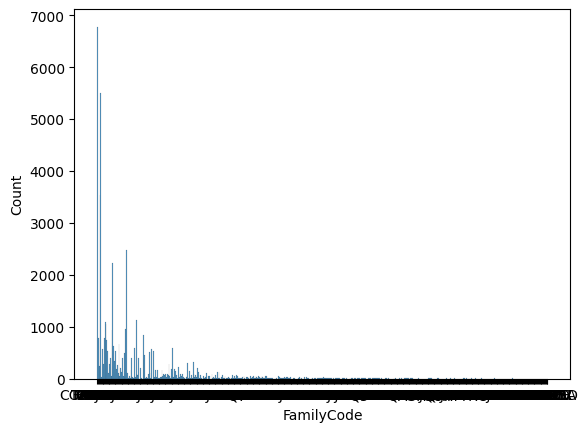

In [32]:
sns.histplot(feature_df['FamilyCode'])

In [33]:
feature_df['FamilyCode'].value_counts()

FamilyCode
COMMODO    6778
FALCON     5498
CAMRY      3539
HILUX      2476
COROLLA    2234
           ... 
SKYLINE       1
PREMACY       1
S280          1
3200GT        1
DB7           1
Name: count, Length: 523, dtype: int64

In [ ]:
def entropy(df: pd.DataFrame, col: str):
    category_counts = df[col].value_counts()
    category_probabilities = category_counts / category_counts.sum()
    entropy = -np.sum(category_probabilities * np.log2(category_probabilities))
    max_entropy = np.log2(len(df[col].unique().tolist())) #max entropy = log2(cardinality)
    return entropy, max_entropy

FamilyCode is somewhat skewed, which makes sense as the mode does not entirely dominate the distribution of the categories

In [35]:
print(f"Proportion under Mode: {feature_df['FamilyCode'].value_counts(ascending=False).iloc[0]/len(feature_df)*100}%")
print(f"Number of Categories: {len(feature_df['FamilyCode'].unique())}")
print(f"Entropy: {entropy(feature_df, 'FamilyCode')[0]}")
print(f"Max Entropy: {entropy(feature_df, 'FamilyCode')[1]}")

Proportion under Mode: 13.695972842449839%
Number of Categories: 523
Entropy: 5.827421875861524
Max Entropy: 9.030667136246942


I want to look at some columns that could be used as alternative desriptors to FamilyCode

In [37]:
feature_df.columns

Index(['MakeCode', 'FamilyCode', 'BodyStyleDescription', 'VFactsClass',
       'FuelTypeDescription', 'EngineTypeDescription', 'GearNum', 'EngineSize',
       'Cylinders', 'Power', 'PowerRPMTo', 'Torque', 'TorqueRPMTo', 'DoorNum',
       'WheelBase', 'Height', 'Length', 'Width', 'KerbWeight', 'SeatCapacity',
       'YearGroup', 'MonthGroup', 'Sold_Date', 'Age_Comp_Months', 'KM',
       'AverageKM', 'GoodKM', 'Colour', 'SaleCategory', 'Branch',
       'BuildCountryOriginDescription', 'NewPrice', 'Sold_Amount'],
      dtype='object')

Aside from just grouping by the year, we also have to consider the brand and year the car was made in, as those would definitely also affect sold price for a given model!

In [38]:
feature_df.groupby(['MakeCode','YearGroup','FamilyCode'])['Sold_Amount'].mean()

MakeCode  YearGroup  FamilyCode
ALFA      1990       ALFA75         3000.0
          1998       GTV           12200.0
          1999       156            7662.5
          2000       156           19650.0
                     SPIDER        11400.0
                                    ...   
VOLV      2011       XC90          53000.0
          2012       S40           22500.0
                     XC60          50500.0
          2013       V40           32000.0
                     V40CROS       28600.0
Name: Sold_Amount, Length: 2929, dtype: float64

In [40]:
feature_df.groupby(['MakeCode','YearGroup','FamilyCode'])['Sold_Amount'].median()

MakeCode  YearGroup  FamilyCode
ALFA      1990       ALFA75         3000.0
          1998       GTV           12200.0
          1999       156            7525.0
          2000       156           19650.0
                     SPIDER        11400.0
                                    ...   
VOLV      2011       XC90          53000.0
          2012       S40           22500.0
                     XC60          50500.0
          2013       V40           32000.0
                     V40CROS       28600.0
Name: Sold_Amount, Length: 2929, dtype: float64

At least for Alfa and Volvo, seems quite reasonable to just use the Class and Power as a descriptor of Model (FamilyCode)

In [39]:
feature_df.groupby(['MakeCode','VFactsClass','YearGroup','Power'])['Sold_Amount'].mean()

MakeCode  VFactsClass  YearGroup  Power
ALFA      Passenger    1990       115.0     3000.000000
                       1998       162.0    12200.000000
                       1999       114.0     5683.333333
                                  140.0    13600.000000
                       2000       114.0    15525.000000
                                               ...     
VOLV      SUV          2010       136.0    41750.000000
                                  151.0    29404.000000
                       2011       147.0    53000.000000
                                  151.0    39420.000000
                       2012       224.0    50500.000000
Name: Sold_Amount, Length: 4209, dtype: float64

In [41]:
feature_df.groupby(['MakeCode','VFactsClass','YearGroup','Power'])['Sold_Amount'].median()

MakeCode  VFactsClass  YearGroup  Power
ALFA      Passenger    1990       115.0     3000.0
                       1998       162.0    12200.0
                       1999       114.0     5950.0
                                  140.0    13600.0
                       2000       114.0    15525.0
                                            ...   
VOLV      SUV          2010       136.0    41750.0
                                  151.0    33500.0
                       2011       147.0    53000.0
                                  151.0    39420.0
                       2012       224.0    50500.0
Name: Sold_Amount, Length: 4209, dtype: float64

Let's do a regression test using RandomForestRegressor to check out how well the two feature sets perform on predicting Sold_Amount. I am choosing this model for the following reasons:
1. High dimensionality of the data (FamilyCode has 523 unique features that will be encoded)
2. We do not yet know if all relationships in the dataset are linear
3. We have not yet handled outliers and missing data

In [42]:
feature_df.describe(include="O")

,MakeCode,FamilyCode,BodyStyleDescription,VFactsClass,FuelTypeDescription,EngineTypeDescription,Sold_Date,Colour,SaleCategory,Branch,BuildCountryOriginDescription
count,49489,49489,49489,49489,49489,49489,49489,49489,49489,49489,49489
unique,49,523,15,4,6,3,4734,897,6,18,30
top,TOYO,COMMODO,Sedan,Passenger,Petrol - Unleaded ULP,Piston,2015-07-01 00:00:00.000,White,Auction,Belmore (NSW),AUSTRALIA
freq,15382,6778,20417,31583,37699,48639,62,15105,37636,14728,23183


<Axes: xlabel='Sold_Amount', ylabel='Count'>

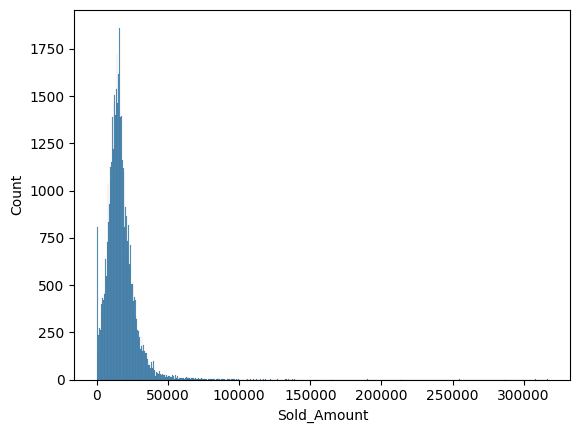

In [43]:
sns.histplot(feature_df['Sold_Amount'])

In [44]:
feature_df['Sold_Amount'].describe()

count     49489.000000
mean      16538.439314
std       10252.650137
min           0.000000
25%       10700.000000
50%       15100.000000
75%       20500.000000
max      317000.000000
Name: Sold_Amount, dtype: float64

Sold_Amount is definitely skewed. For the sake of this experiment, let me do a log transform so the training is not heavily influenced by this right skew

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

feature_set1 = ['MakeCode','YearGroup','VFactsClass','Power','FamilyCode']
feature_set2 = ['MakeCode','YearGroup','VFactsClass','Power']

X1 = feature_df[feature_set1]
X2 = feature_df[feature_set2]
y = np.log1p(feature_df['Sold_Amount']) # we have 0 values, an outlier we will handle later, but for now lets use log (1 + x) to handle that

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

numeric_features1 = X1.select_dtypes(include=['int64', 'float64']).columns
categorical_features1 = X1.select_dtypes(include=['object']).columns

numeric_features2 = X2.select_dtypes(include=['int64', 'float64']).columns
categorical_features2 = X2.select_dtypes(include=['object']).columns

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features1),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features1)
    ])

preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features2),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features2)
    ])

model1 = Pipeline(steps=[('preprocessor', preprocessor1),
                         ('regressor', RandomForestRegressor(random_state=42))])
model2 = Pipeline(steps=[('preprocessor', preprocessor2),
                         ('regressor', RandomForestRegressor(random_state=42))])

# Train models
model1.fit(X1_train, y_train)
model2.fit(X2_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['YearGroup', 'Power'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['MakeCode', 'VFactsClass'], dtype='object'))])),
                ('regressor', RandomForestRegressor(random_state=42))])

Seems to be some level of improvement (Feature Set 2 was the one that included the additional FamilyCode for prediction), although change is not so significant.

In [ ]:
from sklearn.metrics import root_mean_squared_error
y_pred1 = model1.predict(X1_test)
y_pred2 = model2.predict(X2_test)

mae1 = mean_absolute_error(y_test, y_pred1)
rmse1 = root_mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = root_mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print(f"Feature Set 1 - MAE: {mae1}, RMSE: {rmse1}, R²: {r2_1}")
print(f"Feature Set 2 - MAE: {mae2}, RMSE: {rmse2}, R²: {r2_2}")

Feature Set 1 - MAE: 0.5366310721300861, RMSE: 1.2221302230717639, R²: 0.06442225306177207
Feature Set 2 - MAE: 0.5350098165171775, RMSE: 1.2178134938807899, R²: 0.07101975501487823


I will drop FamilyCode, given that we are seeing minimal improvement in model performance with this feature

In [ ]:
feature_df['FamilyCode'].to_csv('FamilyCodes.csv')

In [47]:
feature_df.drop(columns='FamilyCode', inplace= True)

In [ ]:
# feature_df['FamilyCode'] = pd.read_csv('FamilyCodes.csv')['FamilyCode'].values

In [48]:
feature_df.shape

(49489, 32)

In [49]:
feature_df.describe()

,GearNum,EngineSize,Cylinders,Power,PowerRPMTo,Torque,TorqueRPMTo,DoorNum,WheelBase,Height,Length,Width,KerbWeight,SeatCapacity,YearGroup,MonthGroup,Age_Comp_Months,KM,AverageKM,GoodKM,NewPrice,Sold_Amount
count,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,49489.000000,4.948900e+04,49489.000000,49489.000000,49489.000000,49489.000000
mean,4.618178,2997.473418,5.059003,136.970913,5262.865485,286.478894,3463.531532,4.136050,2794.955384,1575.265210,4770.707511,1810.270646,1583.274505,4.893633,2005.425125,1.492231,44.231930,8.297352e+04,299.840268,184.545050,36754.104346,16538.439314
std,0.961923,928.575621,1.121586,41.703933,873.958939,89.009470,848.706757,0.854125,192.435268,180.537998,316.300982,78.253937,276.479073,1.256732,5.013981,3.009728,29.137553,7.116483e+04,131.300160,82.966743,15201.127955,10252.650137
min,1.000000,698.000000,2.000000,32.000000,3000.000000,67.000000,1200.000000,2.000000,1390.000000,1150.000000,2500.000000,1395.000000,720.000000,2.000000,1990.000000,0.000000,0.000000,0.000000e+00,35.000000,20.000000,11000.000000,0.000000
25%,4.000000,2359.000000,4.000000,105.000000,4900.000000,218.000000,2800.000000,4.000000,2670.000000,1450.000000,4625.000000,1760.000000,1450.000000,5.000000,2002.000000,0.000000,26.000000,4.057100e+04,200.000000,120.000000,29610.000000,10700.000000
50%,4.000000,2982.000000,5.000000,132.000000,5250.000000,304.000000,3600.000000,4.000000,2788.000000,1482.000000,4856.000000,1820.000000,1582.000000,5.000000,2006.000000,0.000000,38.000000,6.717900e+04,275.000000,180.000000,34990.000000,15100.000000
75%,5.000000,3791.000000,6.000000,165.000000,6000.000000,354.000000,4100.000000,5.000000,2919.000000,1705.000000,4940.000000,1864.000000,1704.000000,5.000000,2010.000000,1.000000,53.000000,1.140000e+05,400.000000,240.000000,41210.000000,20500.000000
max,9.000000,6467.000000,12.000000,449.000000,8500.000000,800.000000,7500.000000,5.000000,4332.000000,2930.000000,7345.000000,2359.000000,2942.000000,14.000000,2015.000000,12.000000,1279.000000,8.883234e+06,810.000000,540.000000,473697.000000,317000.000000


In [50]:
feature_df.describe(include="O")

,MakeCode,BodyStyleDescription,VFactsClass,FuelTypeDescription,EngineTypeDescription,Sold_Date,Colour,SaleCategory,Branch,BuildCountryOriginDescription
count,49489,49489,49489,49489,49489,49489,49489,49489,49489,49489
unique,49,15,4,6,3,4734,897,6,18,30
top,TOYO,Sedan,Passenger,Petrol - Unleaded ULP,Piston,2015-07-01 00:00:00.000,White,Auction,Belmore (NSW),AUSTRALIA
freq,15382,20417,31583,37699,48639,62,15105,37636,14728,23183


In [ ]:
import config
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(api_key=config.api_key)

color_df = pd.DataFrame()
color_df['Colour'] = feature_df['Colour'].unique().tolist()
color_df['Colour'].tolist()

['White',
 '040 - Glacier White (T)',
 '061 - Diamond White (T)',
 'Pearl White',
 'Winter White',
 'Dynamic White',
 '068 - Snowcap White (T)',
 'Heron White',
 'Fuji White',
 'Satin White',
 '058 - White solid (T)',
 '070 - Pearl White (T)',
 'Casablanca White',
 'White Solid',
 'Cool White',
 'Polar White',
 'Frozen White',
 'Super White',
 'Alpine White',
 'Glacier White ',
 'Arctic White',
 'Solid White',
 'Noble White',
 '056 - White (T)',
 'Super White II',
 'QXA - Pearl White (R)',
 '37J - Satin White Pearl (T)',
 '650 - Calcite White (MB)',
 'Vanilla White',
 'Crystal White Pearl',
 'Pepper White',
 '045 - White Solid (T)',
 'Artic White',
 'Stark White',
 'Pure White',
 'Crystal White',
 'Candy White',
 'Mawson White',
 'B4B4 - Candy White (VW)',
 'Ceramic White',
 '073 - White (T)',
 'Taffeta White',
 'White Satin',
 'W7 - Taffeta White (H)',
 'QNC - Pearl White (R)',
 'Olympic White',
 '082 - Glacier White',
 'Premium White',
 'Creamy White',
 '2KB - Titanium/White Roof (T)

Lets remove anything before the - and anything in brackets (), as they seem to be identifiers instead of colors

In [10]:
import re
color_df['Colour Cleaned'] = color_df['Colour'].apply(lambda x: re.sub(r'^.*-\s*|\(.*?\)', '', x).strip().lower())
color_df['Colour Cleaned'].duplicated().sum()

61

Some duplicates, but is fine, we will use async call of embedding model to embed our colors

In [11]:
colors_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet', 'black', 'white', 'gray']
colors_list_embeddings = await embeddings_model.aembed_documents(colors_list)

We are essentially running a mini RAG type of mechanism to match the unique color names with the core color names (ROYGBIV + BWG)

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def group_colors(embedder: OpenAIEmbeddings, color_desc: str, color_list: list, colors_list_embeddings: list):
    desc_embed = embedder.embed_query(color_desc)
    similarities = cosine_similarity([desc_embed], colors_list_embeddings)
    top_colors = sorted(zip(colors_list, similarities[0]), key=lambda x: x[1], reverse=True)
    return top_colors[0][0]

color_df['Group'] = color_df['Colour Cleaned'].apply(lambda x: group_colors(embeddings_model, x, colors_list, colors_list_embeddings) if x.lower() not in colors_list else x)

That took a while (actually I could definitely do it as aembed_documents() but its cleaner to extract out the top color group this way)). Let's take a look at what our groupings look like

In [14]:
color_df.groupby('Group')['Colour Cleaned'].unique()

Group
black     [steel, black, ebony, obsidian black, brown, p...
blue      [icon blue, dark blue, blue, dynamic blue, fla...
gray      [mercury silver, silver ash, dark grey metalli...
green     [green, harvest green, verdant green, illusion...
indigo    [monsoon, nitro, martini mica, kashmir, karma,...
orange    [orange clay, ego, orange, orion frost, sunris...
red       [red, maroon, bronze, red hot, burra, orpheus ...
violet    [quicksilver, nitrate, cherry, tungsten mica, ...
white     [white, glacier white, diamond white, pearl wh...
yellow    [silver, silver pearl, yellow  white, gold, pu...
Name: Colour Cleaned, dtype: object

Not the greatest grouping but it somewhat works, considering the naming conventions used for the colors. Let me do some manual cleanup then let's pass it back to the dataframe.

In [15]:
cg_corrections= [{'Colour Cleaned': 'steel', 'Group': 'gray'},
                 {'Colour Cleaned': 'silver', 'Group': 'gray'},
                 {'Colour Cleaned': 'silver pearl', 'Group': 'gray'},
                 {'Colour Cleaned': 'quicksilver', 'Group': 'gray'}]

In [16]:
for kvs in cg_corrections:
    color_df.loc[lambda x: x['Colour Cleaned']==kvs['Colour Cleaned'], 'Group'] = kvs['Group']

Thats better

In [17]:
color_df.groupby('Group')['Colour Cleaned'].unique()

Group
black     [black, ebony, obsidian black, brown, phantom ...
blue      [icon blue, dark blue, blue, dynamic blue, fla...
gray      [quicksilver, silver, mercury silver, silver a...
green     [green, harvest green, verdant green, illusion...
indigo    [monsoon, nitro, martini mica, kashmir, karma,...
orange    [orange clay, ego, orange, orion frost, sunris...
red       [red, maroon, bronze, red hot, burra, orpheus ...
violet    [nitrate, cherry, tungsten mica, burgundy, che...
white     [white, glacier white, diamond white, pearl wh...
yellow    [yellow  white, gold, purple, diamond white., ...
Name: Colour Cleaned, dtype: object

It was expensive running the embedding model to group the colors. Let's save it in a dataframe so we dont need to run this again in future.

In [18]:
color_df.to_csv("ColorGroups.csv", index=False)

Time to join this back with our dataset

In [57]:
color_df = pd.read_csv('ColorGroups.csv')

In [63]:
feature_df = pd.merge(feature_df, color_df, on='Colour', how='left')

In [64]:
feature_df.head()

,MakeCode,BodyStyleDescription,VFactsClass,FuelTypeDescription,EngineTypeDescription,GearNum,EngineSize,Cylinders,Power,PowerRPMTo,Torque,TorqueRPMTo,DoorNum,WheelBase,Height,Length,Width,KerbWeight,SeatCapacity,YearGroup,MonthGroup,Sold_Date,Age_Comp_Months,KM,AverageKM,GoodKM,Colour,SaleCategory,Branch,BuildCountryOriginDescription,NewPrice,Sold_Amount,Colour Cleaned,Group
0,HOLD,Sedan,Passenger,Petrol - Unleaded ULP,Piston,4.0,3565,6,180.0,6000.0,330.0,2600.0,4,2915.0,1476.0,4894.0,1899.0,1690.0,5.0,2008,0,2015-11-03 00:00:00.000,93.0,227878.0,230.0,140.0,White,Auction,Perth (WA),AUSTRALIA,34790.0,2000.0,white,white
1,HOLD,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3791,6,130.0,4800.0,295.0,3200.0,5,2822.0,1478.0,4903.0,1794.0,1380.0,5.0,1993,7,2000-10-18 00:00:00.000,86.0,153091.0,600.0,360.0,Red,Auction,Belmore (NSW),AUSTRALIA,27978.0,6800.0,red,red
2,TOYO,Wagon,SUV,Petrol - Unleaded ULP,Piston,5.0,2362,4,125.0,6000.0,224.0,4000.0,5,2660.0,1695.0,4625.0,1815.0,1545.0,5.0,2012,0,2014-02-05 00:00:00.000,16.0,27374.0,130.0,80.0,040 - Glacier White (T),Dealer Only Auction,Sunshine (VIC),JAPAN,31990.0,22900.0,glacier white,white
3,HOLD,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3565,6,172.0,6000.0,320.0,2800.0,5,2938.0,1527.0,5033.0,1847.0,1576.0,5.0,2007,0,2011-01-10 00:00:00.000,48.0,99452.0,250.0,150.0,Quicksilver,Auction,Belmore (NSW),AUSTRALIA,35990.0,10500.0,quicksilver,gray
4,TOYO,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,2362,4,125.0,6000.0,224.0,4000.0,5,2950.0,1750.0,4795.0,1800.0,1725.0,8.0,2007,0,2009-05-23 00:00:00.000,28.0,44355.0,250.0,150.0,Silver,Special Fixed Price,Hobart (TAS),JAPAN,49490.0,31320.0,silver,gray


Color transformation complete

In [65]:
feature_df.drop(columns=['Colour','Colour Cleaned'], inplace=True)
feature_df.rename(columns={'Group':'ColorGroup'}, inplace=True)
feature_df

,MakeCode,BodyStyleDescription,VFactsClass,FuelTypeDescription,EngineTypeDescription,GearNum,EngineSize,Cylinders,Power,PowerRPMTo,Torque,TorqueRPMTo,DoorNum,WheelBase,Height,Length,Width,KerbWeight,SeatCapacity,YearGroup,MonthGroup,Sold_Date,Age_Comp_Months,KM,AverageKM,GoodKM,SaleCategory,Branch,BuildCountryOriginDescription,NewPrice,Sold_Amount,ColorGroup
0,HOLD,Sedan,Passenger,Petrol - Unleaded ULP,Piston,4.0,3565,6,180.0,6000.0,330.0,2600.0,4,2915.0,1476.0,4894.0,1899.0,1690.0,5.0,2008,0,2015-11-03 00:00:00.000,93.0,227878.0,230.0,140.0,Auction,Perth (WA),AUSTRALIA,34790.0,2000.0,white
1,HOLD,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3791,6,130.0,4800.0,295.0,3200.0,5,2822.0,1478.0,4903.0,1794.0,1380.0,5.0,1993,7,2000-10-18 00:00:00.000,86.0,153091.0,600.0,360.0,Auction,Belmore (NSW),AUSTRALIA,27978.0,6800.0,red
2,TOYO,Wagon,SUV,Petrol - Unleaded ULP,Piston,5.0,2362,4,125.0,6000.0,224.0,4000.0,5,2660.0,1695.0,4625.0,1815.0,1545.0,5.0,2012,0,2014-02-05 00:00:00.000,16.0,27374.0,130.0,80.0,Dealer Only Auction,Sunshine (VIC),JAPAN,31990.0,22900.0,white
3,HOLD,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3565,6,172.0,6000.0,320.0,2800.0,5,2938.0,1527.0,5033.0,1847.0,1576.0,5.0,2007,0,2011-01-10 00:00:00.000,48.0,99452.0,250.0,150.0,Auction,Belmore (NSW),AUSTRALIA,35990.0,10500.0,gray
4,TOYO,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,2362,4,125.0,6000.0,224.0,4000.0,5,2950.0,1750.0,4795.0,1800.0,1725.0,8.0,2007,0,2009-05-23 00:00:00.000,28.0,44355.0,250.0,150.0,Special Fixed Price,Hobart (TAS),JAPAN,49490.0,31320.0,gray
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49484,FORD,Hatchback,Passenger,Diesel,Piston,6.0,1997,4,120.0,4000.0,340.0,2250.0,5,2850.0,1500.0,4778.0,1886.0,1595.0,5.0,2011,0,2015-02-18 00:00:00.000,37.0,100184.0,150.0,90.0,Dealer Only Auction,Geebung (QLD),BELGIUM,39740.0,11800.0,gray
49485,HOLD,Wagon,Passenger,Petrol - Unleaded ULP,Piston,4.0,3791,6,152.0,5200.0,305.0,3600.0,5,2938.0,1545.0,5046.0,1847.0,1555.0,5.0,2002,0,2008-07-15 00:00:00.000,72.0,171614.0,375.0,225.0,Auction,Tullamarine (VIC),AUSTRALIA,33570.0,3450.0,yellow
49486,HYUN,Wagon,Passenger,Diesel,Piston,4.0,1582,4,85.0,4000.0,255.0,2750.0,5,2700.0,1520.0,4475.0,1775.0,1449.0,5.0,2009,0,2013-05-27 00:00:00.000,39.0,95183.0,200.0,120.0,Auction,Geebung (QLD),SOUTH KOREA,26390.0,11700.0,blue
49487,FORD,Sedan,Passenger,Petrol - Unleaded ULP,Piston,4.0,3984,6,182.0,5000.0,380.0,3250.0,4,2829.0,1444.0,4916.0,1864.0,1648.0,5.0,2003,0,2008-03-26 00:00:00.000,55.0,88088.0,350.0,210.0,Auction,Geebung (QLD),AUSTRALIA,34660.0,8600.0,white


In [66]:
from typing import List
class FeatureAnalyzer():
    def __init__(self, df: pd.DataFrame, features_of_interest: List = []):
        if features_of_interest == []:
            self.df = df
        else:
            self.df = df[features_of_interest]
            
    def show_feature_dist(self):
        num_plots = len(self.df.columns)
        cols = 3
        rows = (num_plots + cols - 1) // cols
        _, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
        axes = axes.flatten()
        for i, col in enumerate(self.df.columns):
            # print(col)
            if self.df[col].dtype != "O":
                sns.histplot(self.df[col], kde = True, ax=axes[i])
                mu = self.df[col].mean()
                skew  = stats.skew(self.df[col], nan_policy='omit')
                axes[i].axvline(mu, color='red',linestyle='--',label=f"Mean: {mu}")
                axes[i].text(0.75, 0.85, f"Skew: {skew:.2f}",transform=axes[i].transAxes, fontsize=12,
                            verticalalignment='top', horizontalalignment='center', color='blue')
            else:
                sns.histplot(self.df[col], ax=axes[i])
                axes[i].set_xticklabels([])
                axes[i].set_xticks([])
            axes[i].set_title(f"Distribution of {col}")
        plt.show()

    def outlier_dist(self):
        num_plots = len(self.df.describe().T.index)
        cols = 2
        rows = (num_plots + cols - 1) // cols
        _, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        axes = axes.flatten()
        for i, col in enumerate(self.df.describe().T.index):
            sns.boxplot(self.df[col], ax=axes[i])
            axes[i].set_title(f"Box Plot of {col}")
        plt.show()

In [67]:
feature_analyzer = FeatureAnalyzer(feature_df)

Observations:
1. Can change Numeric to Categorical: GearNum, Cylinders, DoorNum, SeatCapacity
2. Predominant Right Skewness
3. Price Data (NewPrice, Sold_Amount) is quite skewed, and KM is insanely skewed (definitely a few outliers to deal with there)

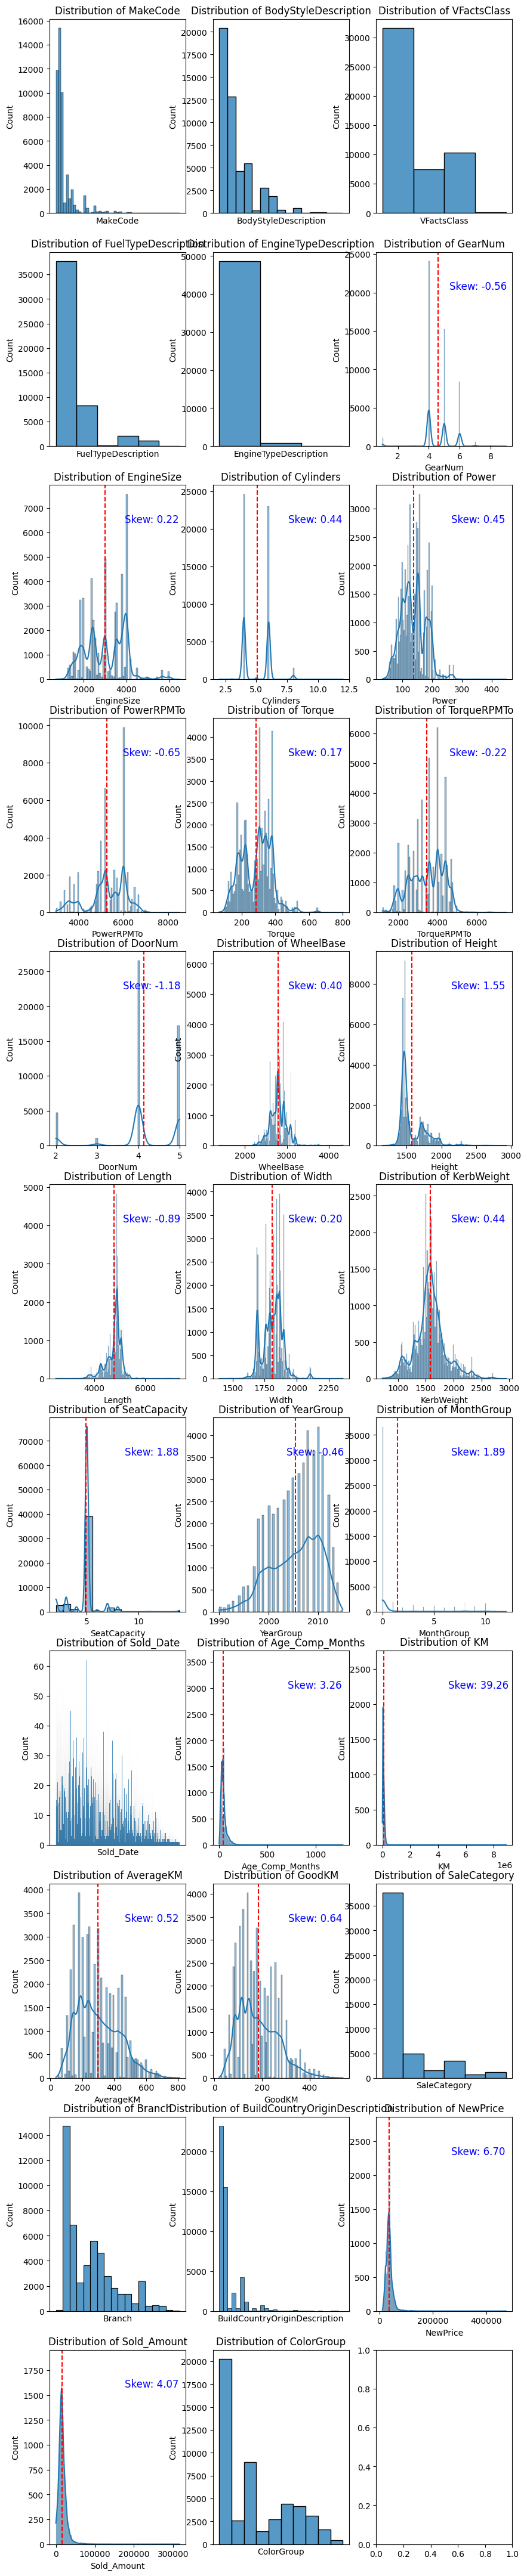

In [68]:
feature_analyzer.show_feature_dist()

Observations:
1. Definite outliers: Age_Comp_Months, KM (max values way above Q3)
2. Weird outliers: Sold_Amount (we have cars with near 0 value, does this even make sense, especially for new cars??? High prices understandable, especially if we are talking about luxury vehicles)
3. Remainder of data looks okay, but I want to look at it in terms of IQR range, particularly Power, PowerRPMTo, Torque, TorqueRPMTo, Height, Length, Width, KerbWeight

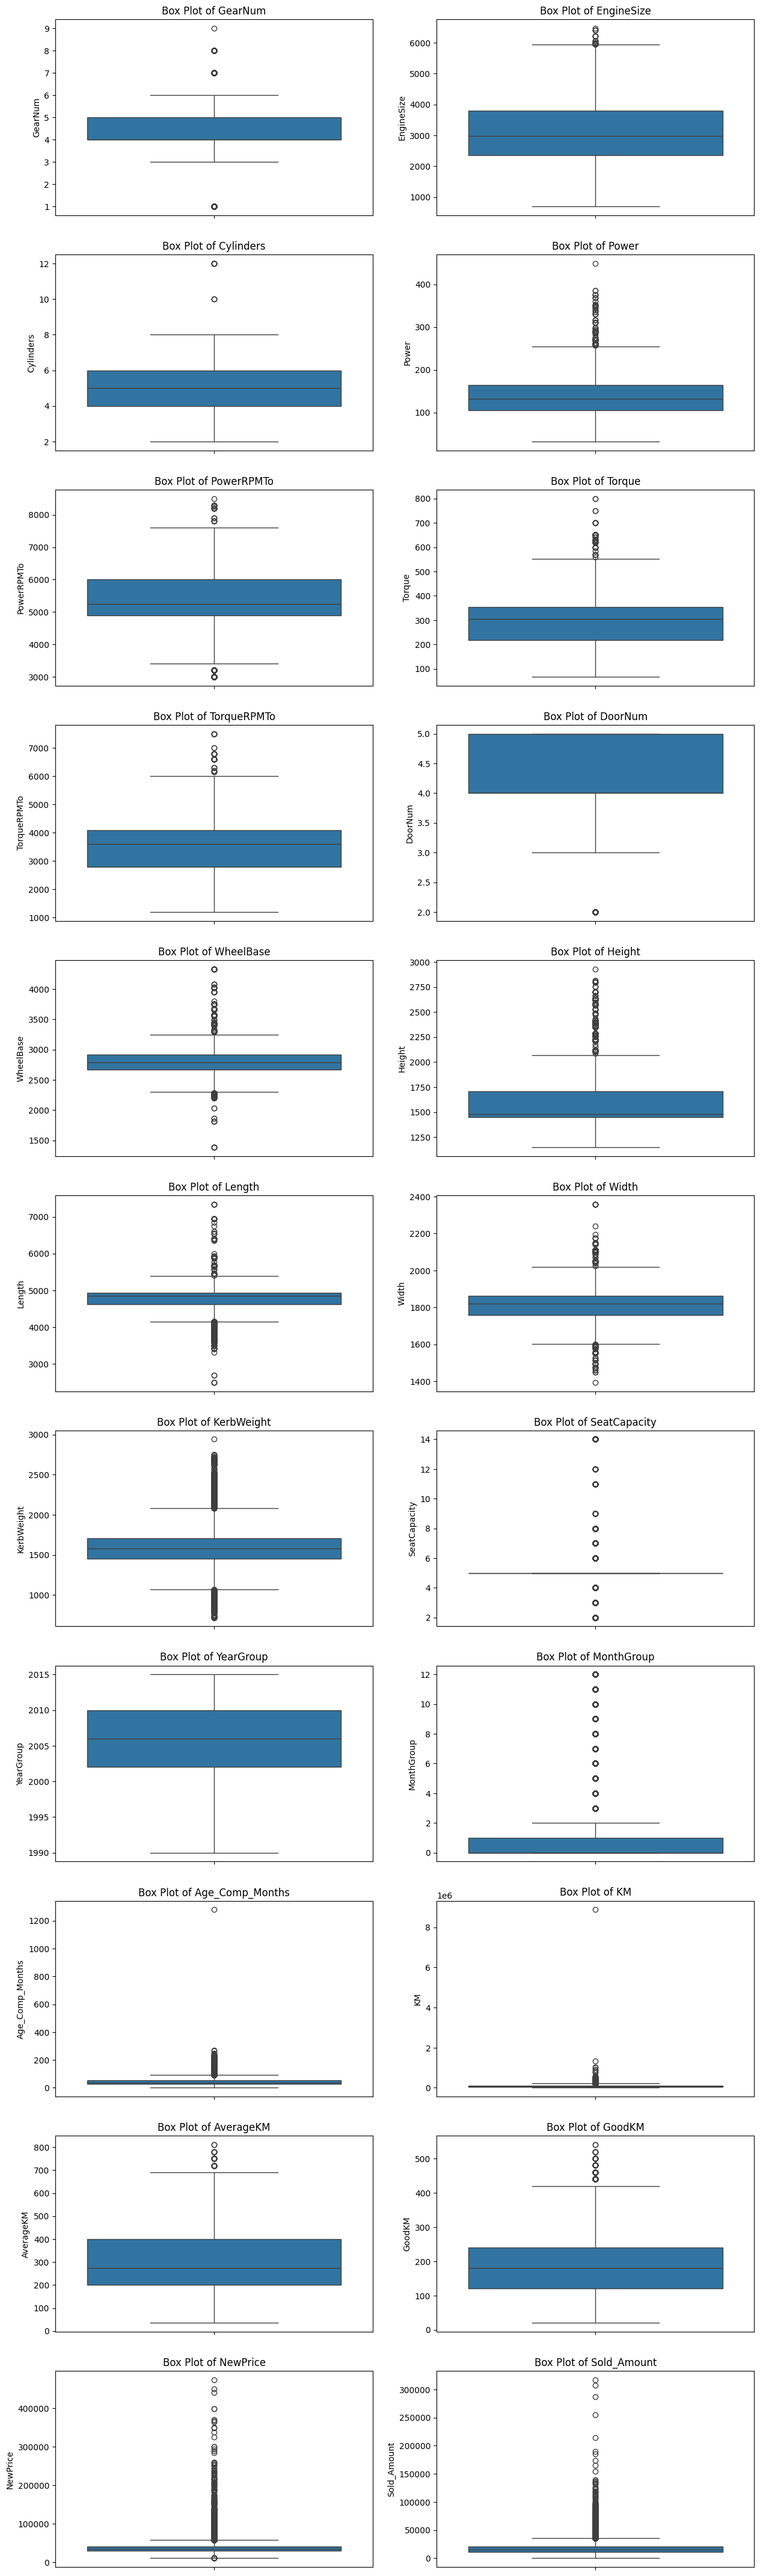

In [69]:
feature_analyzer.outlier_dist()

In [70]:
def outlier_stats(df, col):
    print(df[col].describe())

    print("\n")

    first_percentile = df[col].quantile(0.01)
    ninety9th_percentile = df[col].quantile(0.99)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    lower = q1 - (1.5* iqr)
    upper = q3 + (1.5 * iqr)
    print("1st: ", first_percentile)
    print("99th: ", ninety9th_percentile)
    print("Lower Bound: ", lower)
    print("Upper Bound: ", upper)

Let's start with Sold_Amount since that is what we want to predict. Its definitely strange that we have quite a number of free cars (Sold_Amount = 0) in our dataset!

In [71]:
outlier_stats(feature_df, 'Sold_Amount')

count     49489.000000
mean      16538.439314
std       10252.650137
min           0.000000
25%       10700.000000
50%       15100.000000
75%       20500.000000
max      317000.000000
Name: Sold_Amount, dtype: float64


1st:  0.0
99th:  51000.0
Lower Bound:  -4000.0
Upper Bound:  35200.0


Lets drop the free cars from the dataset first

In [74]:
feature_df = feature_df.loc[lambda x: x["Sold_Amount"] > 0]

Im doing a log transformation over the Sold_Amount since the distribution is Right Skewed, that way we can have a better idea of what the outliers look like

In [76]:
feature_df['LogSales'] = feature_df['Sold_Amount'].apply(lambda x: np.log(x))

/var/folders/zk/jyn4pz795tl33j_m94s1rzcr0000gn/T/ipykernel_76017/1348563848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['LogSales'] = feature_df['Sold_Amount'].apply(lambda x: np.log(x))


In [77]:
outlier_stats(feature_df, 'LogSales')

count    48758.000000
mean         9.563819
std          0.625121
min          0.000000
25%          9.305651
50%          9.632335
75%          9.933046
max         12.666657
Name: LogSales, dtype: float64


1st:  7.438383530044307
99th:  10.842380441171192
Lower Bound:  8.36455684728476
Upper Bound:  10.874140059273422


Now that we have removed free cars from the dataset, we can get a clearer picture of the other outliers in Sold_Amount. I think it would be fair to say that we can remove any cars that fall outside the first percentile of the log distribution (~$1700).

In [79]:
np.exp(7.438383530044307)

1699.9999999999993

In [83]:
feature_df = feature_df.loc[lambda x: x["LogSales"] > x['LogSales'].quantile(0.01)]

Outliers in Sold_Amount looks cleaner

<Axes: ylabel='Sold_Amount'>

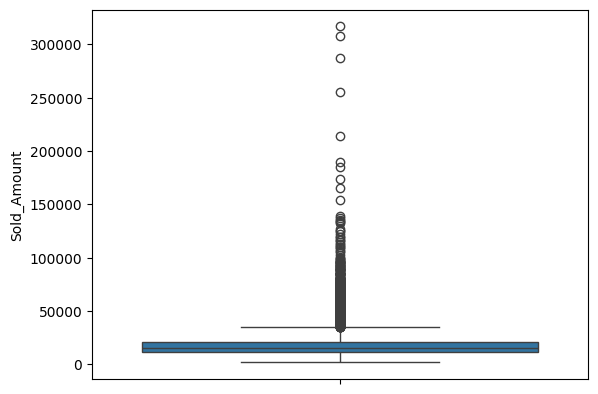

In [85]:
sns.boxplot(feature_df['Sold_Amount'])

The maximum value of KM is way higher than typical mileage. Would people even buy a car if it has been used 8 million KM? Is it possible to use a car up to 8 million KM?

UPDATE: Quick Google search shows the car with the highest mileage in 52 YEARS is 3.2 million miles (5.1 million KM). Given wear and tear, I think it is quite highly unlikely that cars would hit over 1 million KM.

Anyways, our data is very heavily skewed. Let's do a Log transform to have a more even distribution of KM

In [87]:
outlier_stats(feature_df, 'KM')

count    4.826300e+04
mean     8.136537e+04
std      6.958321e+04
min      0.000000e+00
25%      4.034500e+04
50%      6.625600e+04
75%      1.119565e+05
max      8.883234e+06
Name: KM, dtype: float64


1st:  5012.86
99th:  256546.93999999945
Lower Bound:  -67072.25
Upper Bound:  219373.75


Definitely looks like we have outliers on the lower bounds too (NewPrice and Sold_Amount depreciation is significant!)

In [88]:
feature_df.loc[lambda x: x['KM'] == 0]

,MakeCode,BodyStyleDescription,VFactsClass,FuelTypeDescription,EngineTypeDescription,GearNum,EngineSize,Cylinders,Power,PowerRPMTo,Torque,TorqueRPMTo,DoorNum,WheelBase,Height,Length,Width,KerbWeight,SeatCapacity,YearGroup,MonthGroup,Sold_Date,Age_Comp_Months,KM,AverageKM,GoodKM,SaleCategory,Branch,BuildCountryOriginDescription,NewPrice,Sold_Amount,ColorGroup,LogSales
578,TOYO,Cab Chassis,Light Commercial,Diesel,Piston,5.0,4164,6,122.0,3400.0,380.0,1400.0,2,3180.0,1970.0,5075.0,1690.0,2027.000000,3.0,2001,0,2010-02-03 00:00:00.000,109.0,0.0,480.0,320.0,Tender,Belmore (NSW),JAPAN,51590.0,5555.0,white,8.622454
3115,HYUN,Wagon,SUV,Petrol - Unleaded ULP,Piston,4.0,2656,6,138.0,6000.0,248.0,4000.0,5,2700.0,1795.0,4675.0,1890.0,1845.000000,5.0,2006,5,2009-09-08 00:00:00.000,37.0,0.0,275.0,165.0,Tender,Belmore (NSW),SOUTH KOREA,37990.0,19500.0,white,9.878170
3826,MERC,Van,Light Commercial,Diesel,Piston,5.0,2151,4,60.0,3800.0,200.0,2400.0,5,3000.0,1890.0,4660.0,1870.0,1584.000000,2.0,1999,0,2006-01-23 00:00:00.000,76.0,0.0,540.0,360.0,Auction,Geebung (QLD),GERMANY,31750.0,7300.0,white,8.895630
4138,HOLD,Sedan,Passenger,Petrol - Unleaded ULP,Piston,5.0,3565,6,190.0,6500.0,340.0,3200.0,4,2789.0,1440.0,4876.0,1842.0,1592.000000,5.0,2004,8,2012-10-10 00:00:00.000,96.0,0.0,325.0,195.0,Auction,Belmore (NSW),AUSTRALIA,38990.0,6800.0,blue,8.824678
4877,FORD,Utility,Light Commercial,Diesel,Piston,5.0,2499,4,86.0,3500.0,280.0,2000.0,4,3000.0,1753.0,4998.0,1695.0,1755.000000,5.0,2002,11,2008-08-21 00:00:00.000,75.0,0.0,450.0,300.0,Auction,Tamworth (NSW),THAILAND,38060.0,2200.0,white,7.696213
6369,MITS,Utility,Light Commercial,Petrol - Unleaded ULP,Piston,5.0,2972,6,133.0,5250.0,255.0,4500.0,4,2960.0,1780.0,4995.0,1695.0,1630.000000,5.0,2004,10,2009-05-05 00:00:00.000,58.0,0.0,325.0,195.0,Tender,Belmore (NSW),THAILAND,29990.0,11500.0,white,9.350102
8775,FORD,Sedan,Passenger,Petrol - Unleaded ULP,Piston,4.0,3984,6,157.0,4900.0,357.0,3000.0,4,2792.0,1437.0,4907.0,1870.0,1590.000000,5.0,1999,0,2003-10-21 00:00:00.000,56.0,0.0,450.0,270.0,Auction,Tullamarine (VIC),AUSTRALIA,34490.0,13700.0,indigo,9.525151
9650,TOYO,Wagon,SUV,Petrol - Unleaded ULP,Piston,5.0,4664,8,202.0,5400.0,410.0,3400.0,5,2850.0,1905.0,4950.0,1970.0,2665.000000,8.0,2008,0,2009-06-25 00:00:00.000,16.0,0.0,230.0,140.0,Pickles Online,Sunshine (VIC),JAPAN,97217.0,69000.0,black,11.141862
11651,SUBA,Sedan,Passenger,Petrol - Unleaded ULP,Piston,4.0,2457,4,121.0,5600.0,226.0,4400.0,4,2670.0,1425.0,4665.0,1730.0,1385.000000,5.0,2006,0,2008-11-03 00:00:00.000,26.0,0.0,275.0,165.0,Tender,Belmore (NSW),JAPAN,42990.0,11015.0,gray,9.307013
11784,FORD,Sedan,Passenger,Petrol - Unleaded ULP,Piston,4.0,4942,8,165.0,4500.0,388.0,3000.0,4,2919.0,1428.0,5122.0,1861.0,1699.000000,5.0,1997,0,2004-10-05 00:00:00.000,85.0,0.0,500.0,300.0,Auction,Tullamarine (VIC),AUSTRALIA,52267.0,7100.0,green,8.867850


Given the extreme skew of KM, lets drop the outlier KM = 0 cases we saw, then do log transform with base 10 (since KM units typically in 10^3, 10^4, 10^5, 10^6)

In [94]:
feature_df = feature_df.loc[lambda x: x["KM"] > 0]

In [106]:
feature_df['LogKM'] = feature_df['KM'].apply(lambda x: np.log10(x))

/var/folders/zk/jyn4pz795tl33j_m94s1rzcr0000gn/T/ipykernel_76017/4503365.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['LogKM'] = feature_df['KM'].apply(lambda x: np.log10(x))


In [107]:
feature_df['LogKM'].skew()

-1.6716621567243706

Still skewed, in this case I will just rely on IQR for handling outliers

<Axes: xlabel='LogKM', ylabel='Count'>

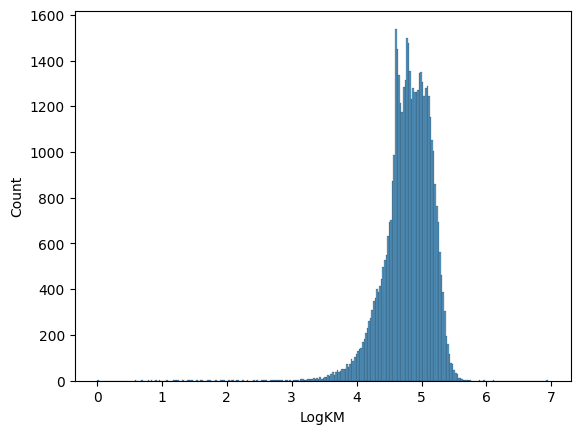

In [109]:
sns.histplot(feature_df['LogKM'])

In [110]:
outlier_stats(feature_df, 'LogKM')

count    48225.000000
mean         4.791509
std          0.365458
min          0.000000
25%          4.606231
50%          4.821487
75%          5.049199
max          6.948571
Name: LogKM, dtype: float64


1st:  3.718209287035435
99th:  5.409303808971741
Lower Bound:  3.941779151214647
Upper Bound:  5.713650323816626


I have decided to limit the data to whatever lies between the upper and lower bounds computed by IQR, since even after log transformation data is still skewed

In [114]:
feature_df = feature_df.loc[lambda x: (x["LogKM"] > 3.941779151214647) & (x["LogKM"] < 5.713650323816626)]

In [117]:
feature_df.shape

(47178, 34)

100 year compliance seems odd

In [118]:
outlier_stats(feature_df, 'Age_Comp_Months')

count    47178.000000
mean        43.908326
std         27.357142
min          1.000000
25%         26.000000
50%         38.000000
75%         53.000000
max       1279.000000
Name: Age_Comp_Months, dtype: float64


1st:  9.0
99th:  137.0
Lower Bound:  -14.5
Upper Bound:  93.5


Let's use Year and month to calculate Aging in order to find anomalies in Age_Comp_Months

In [122]:
feature_df.columns

Index(['MakeCode', 'BodyStyleDescription', 'VFactsClass',
       'FuelTypeDescription', 'EngineTypeDescription', 'GearNum', 'EngineSize',
       'Cylinders', 'Power', 'PowerRPMTo', 'Torque', 'TorqueRPMTo', 'DoorNum',
       'WheelBase', 'Height', 'Length', 'Width', 'KerbWeight', 'SeatCapacity',
       'YearGroup', 'MonthGroup', 'Sold_Date', 'Age_Comp_Months', 'KM',
       'AverageKM', 'GoodKM', 'SaleCategory', 'Branch',
       'BuildCountryOriginDescription', 'NewPrice', 'Sold_Amount',
       'ColorGroup', 'LogSales', 'LogKM'],
      dtype='object')

Year seems fine (1990-2015): definitely indicates that a 100 year old compliance is an outlier
Month not so much, alot of it is 0, im assuming it means the value is unknown. I think we should drop this column, since more than 70% of the data is "missing"/unknown.

In [124]:
feature_df[['YearGroup','MonthGroup','Sold_Date']].describe()

,YearGroup,MonthGroup
count,47178.000000,47178.000000
mean,2005.386367,1.480881
std,4.953850,3.000665
min,1990.000000,0.000000
25%,2002.000000,0.000000
50%,2006.000000,0.000000
75%,2009.000000,1.000000
max,2015.000000,12.000000


In [127]:
feature_df['MonthGroup'].value_counts() / len(feature_df) * 100

MonthGroup
0     74.191360
1      4.124804
8      3.813218
10     3.402009
3      2.564755
5      2.234092
9      2.123871
4      1.784730
6      1.763534
7      1.757175
2      1.498580
11     0.462080
12     0.279791
Name: count, dtype: float64

In [123]:
feature_df[['YearGroup','MonthGroup','Sold_Date']].describe(include="O")

,Sold_Date
count,47178
unique,4717
top,2015-05-20 00:00:00.000
freq,57


In [128]:
feature_df.drop(columns='MonthGroup', inplace=True)

Let's now calculate Aging based on Sold Date and Year of Manufacture

In [129]:
feature_df['Aging'] = feature_df.apply(lambda row: int(row['Sold_Date'][:4]) - row['YearGroup'],axis=1)

Max Years is 22, which is 22 * 12 = 264. Impossible we got age_comp is 100 years

In [130]:
feature_df['Aging'].describe()

count    47178.000000
mean         3.660329
std          2.264135
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         22.000000
Name: Aging, dtype: float64

In [131]:
feature_df['AgingMonths'] = feature_df['Aging'].apply(lambda x: x*12)

In [133]:
feature_df['AgingMonths'].describe()

count    47178.000000
mean        43.923948
std         27.169618
min          0.000000
25%         24.000000
50%         36.000000
75%         48.000000
max        264.000000
Name: AgingMonths, dtype: float64

What we can do now is to fix the Aging Compliance with the following rules:
- If Age_Comp_Months > AgingMonths then assume AgingMonths else Age_Comp_Months

In [135]:
feature_df['Age_Comp_Months_Fixed'] = feature_df.apply(lambda row: row['AgingMonths'] if row['Age_Comp_Months'] > row['AgingMonths'] else row['Age_Comp_Months'], axis=1)

In [138]:
feature_df[['AgingMonths','Age_Comp_Months_Fixed']].describe()

,AgingMonths,Age_Comp_Months_Fixed
count,47178.000000,47178.000000
mean,43.923948,41.955445
std,27.169618,26.841184
min,0.000000,0.000000
25%,24.000000,24.000000
50%,36.000000,36.000000
75%,48.000000,48.000000
max,264.000000,264.000000


Distribution for Age Comp looks alot better now

<Axes: ylabel='Age_Comp_Months_Fixed'>

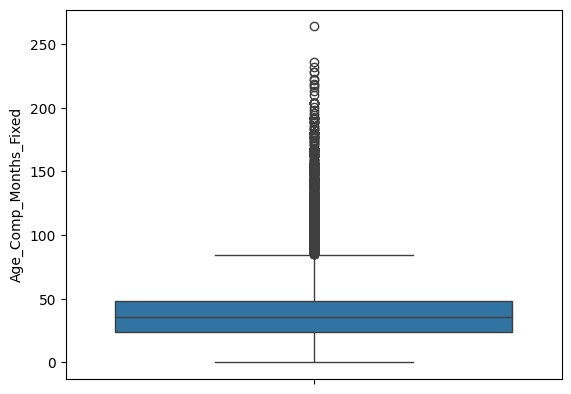

In [142]:
sns.boxplot(feature_df['Age_Comp_Months_Fixed'])

In [143]:
feature_df.columns

Index(['MakeCode', 'BodyStyleDescription', 'VFactsClass',
       'FuelTypeDescription', 'EngineTypeDescription', 'GearNum', 'EngineSize',
       'Cylinders', 'Power', 'PowerRPMTo', 'Torque', 'TorqueRPMTo', 'DoorNum',
       'WheelBase', 'Height', 'Length', 'Width', 'KerbWeight', 'SeatCapacity',
       'YearGroup', 'Sold_Date', 'Age_Comp_Months', 'KM', 'AverageKM',
       'GoodKM', 'SaleCategory', 'Branch', 'BuildCountryOriginDescription',
       'NewPrice', 'Sold_Amount', 'ColorGroup', 'LogSales', 'LogKM', 'Aging',
       'AgingMonths', 'Age_Comp_Months_Fixed'],
      dtype='object')

Let's drop residual columns after the fixes/transformations

In [145]:
feature_df.drop(columns=['Age_Comp_Months'], inplace=True)

Potential features with multicollinearity:
1. EngineSize, Cylinders, Power, Torque
2. KM, AverageKM, GoodKM, LogKM (ofc), Aging, AgingMonths (ofc), Age_Comp_Months_Fixed
3. YearGroup, AverageKM and GoodKM


<Axes: >

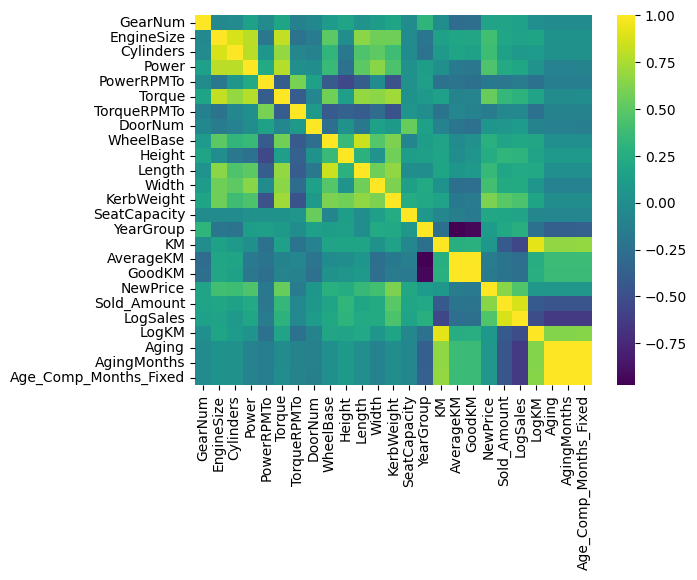

In [204]:
sns.heatmap(feature_df.select_dtypes(include="number").corr(),cmap='viridis')

In [211]:
feature_df.describe().min()

GearNum                      0.953235
EngineSize                 698.000000
Cylinders                    1.121205
Power                       32.000000
PowerRPMTo                 875.214984
Torque                      67.000000
TorqueRPMTo                848.417159
DoorNum                      0.856124
WheelBase                  192.740288
Height                     181.638848
Length                     313.747838
Width                       78.055209
KerbWeight                 275.304286
SeatCapacity                 1.267784
YearGroup                    4.953850
KM                        8749.000000
AverageKM                   35.000000
GoodKM                      20.000000
NewPrice                 11000.000000
Sold_Amount               1750.000000
LogSales                     0.557010
LogKM                        0.308361
Aging                        0.000000
AgingMonths                  0.000000
Age_Comp_Months_Fixed        0.000000
dtype: float64

We will need to drop the AgingMonths column as it is basically just Aging * 12, and will mess with our VIF scoring

In [218]:
feature_df.drop(columns='AgingMonths',inplace=True)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = feature_df.drop(columns=['Sold_Amount','LogSales']).select_dtypes(include="number")
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by='VIF',ascending=False)

In [220]:
vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
14,YearGroup,3220.695875
11,Width,1608.677441
19,LogKM,1581.509927
10,Length,1293.137329
16,AverageKM,1026.746281
17,GoodKM,993.504868
8,WheelBase,902.030792
4,PowerRPMTo,413.333828
3,Power,314.341831
5,Torque,294.899889


Since we have Aging, let's drop a few features to test our new VIFs:
1. Drop YearGroup since we already have Aging
2. Drop LogKM, AverageKM, GoodKM since we already have KM
3. Drop Width, Length, WheelBase, Height since we have KerbWeight (bigger sized car would generally be heavier)

In [ ]:
X = feature_df.drop(columns=['YearGroup','Sold_Amount','LogSales']).select_dtypes(include="number")
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
11,Width,1298.229132
10,Length,1265.142784
15,AverageKM,1026.700207
16,GoodKM,993.367805
18,LogKM,975.932209
8,WheelBase,894.379016
4,PowerRPMTo,372.233509
9,Height,278.586304
3,Power,271.926177
5,Torque,270.229379


In [223]:
X = feature_df.drop(columns=['YearGroup','Sold_Amount','LogSales','LogKM','AverageKM','GoodKM']).select_dtypes(include="number")
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
10,Length,1139.795296
11,Width,1051.373154
8,WheelBase,846.404736
4,PowerRPMTo,336.266816
16,Aging,269.075332
17,Age_Comp_Months_Fixed,262.569533
5,Torque,247.122820
3,Power,234.544508
12,KerbWeight,206.027355
9,Height,205.852761


Still very High VIF values. Let's do some feature engineering to fix this up

In [224]:
X = feature_df.drop(columns=['YearGroup','Sold_Amount','LogSales','LogKM','AverageKM','GoodKM','Width', 'Length', 'WheelBase', 'Height']).select_dtypes(include="number")
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
12,Aging,268.900523
13,Age_Comp_Months_Fixed,262.503376
2,Cylinders,132.861643
5,Torque,132.205461
4,PowerRPMTo,119.012224
1,EngineSize,116.369545
8,KerbWeight,108.671372
3,Power,108.445308
7,DoorNum,38.364390
0,GearNum,29.527254


In [226]:
feature_df['KM per Year'] = feature_df.apply(lambda row: row['KM']/(row['Age_Comp_Months_Fixed']/12) if row['Age_Comp_Months_Fixed'] > 0 else row['KM'], axis=1)

In [228]:
feature_df['KM per Year'].describe()

count     47178.000000
mean      25545.435959
std       13353.370293
min        1464.833333
25%       16547.608696
50%       23054.315399
75%       31680.890110
max      350016.000000
Name: KM per Year, dtype: float64

In [231]:
X = feature_df.drop(columns=['YearGroup','Sold_Amount','LogSales','KM','LogKM','AverageKM','GoodKM','Width', 'Length', 'WheelBase', 'Height']).select_dtypes(include="number")
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
11,Aging,268.973516
12,Age_Comp_Months_Fixed,256.174431
5,Torque,133.168802
2,Cylinders,132.673776
4,PowerRPMTo,120.230124
1,EngineSize,116.546908
3,Power,109.675961
8,KerbWeight,108.390071
7,DoorNum,38.361362
0,GearNum,29.555595


We might want to see how fast the car is relative to its size, which we can do by looking at the Power/Torque compared to the vehicle weight

In [260]:
feature_df['RelativePower'] = feature_df['Power'] / feature_df['KerbWeight']
feature_df['RelativeTorque'] = feature_df['Torque'] / feature_df['KerbWeight']

In [265]:
X = feature_df[['NewPrice','KM per Year','Aging','RelativePower']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
3,RelativePower,8.683793
0,NewPrice,6.919933
1,KM per Year,4.107577
2,Aging,3.141880


Amongst the numeric descriptors, I think we have good features that we can use to predict sales price. We can essentially look at the depreciation of a car based on how much it was originally (NewPrice), Aging, Average Mileage (KM per Year), and Power (RelativePower). I am using RelativePower instead of RelativeTorque due to lower VIF number (ideally we want under 5 or under 10).

Instead of engineering the car descriptors, I am going to exclude them, as they are already described by our categories (BodyStyleDescription, VFactsClass)

In [267]:
feature_df.columns

Index(['MakeCode', 'BodyStyleDescription', 'VFactsClass',
       'FuelTypeDescription', 'EngineTypeDescription', 'GearNum', 'EngineSize',
       'Cylinders', 'Power', 'PowerRPMTo', 'Torque', 'TorqueRPMTo', 'DoorNum',
       'WheelBase', 'Height', 'Length', 'Width', 'KerbWeight', 'SeatCapacity',
       'YearGroup', 'Sold_Date', 'KM', 'AverageKM', 'GoodKM', 'SaleCategory',
       'Branch', 'BuildCountryOriginDescription', 'NewPrice', 'Sold_Amount',
       'ColorGroup', 'LogSales', 'LogKM', 'Aging', 'Age_Comp_Months_Fixed',
       'KM per Year', 'RelativePower', 'RelativeTorque'],
      dtype='object')

In [266]:
X = feature_df[['NewPrice','KM per Year','Aging','RelativeTorque']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
3,RelativeTorque,12.172717
0,NewPrice,7.821829
1,KM per Year,4.501426
2,Aging,3.319977


In [366]:
def add_corrs(axes, idx, df, col, target):
    axes[idx].text(0.5, 0.90, f"{col} Skew: {df[col].skew():.2f}",transform=axes[idx].transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='center', color='blue')
    axes[idx].text(0.75, 0.85, f"Pearson: {df[[col,target]].corr().iloc[0,1]:.2f}",transform=axes[idx].transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='center', color='blue')
    axes[idx].text(0.75, 0.80, f"Spearman: {df[[col,target]].corr(method='spearman').iloc[0,1]:.2f}",transform=axes[idx].transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='center', color='blue')
    axes[idx].text(0.75, 0.75, f"Kendall-Tau: {df[[col,target]].corr(method='kendall').iloc[0,1]:.2f}",transform=axes[idx].transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='center', color='blue')
    
def show_num_rls(df, target1, target2):
    num_plots = len(df.select_dtypes(include="number").columns) * 2
    cols = 2
    rows = (num_plots + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
    axes = axes.flatten()
    
    numeric_columns = df.select_dtypes(include="number").columns
    
    for idx, col in enumerate(numeric_columns):
        
        sns.scatterplot(x=col, y=target1, data=df, ax=axes[idx * 2])
        add_corrs(axes, idx * 2, df, col, target1)
        axes[idx * 2].set_title(f"Relationship between {col} and {target1}")
        
        sns.scatterplot(x=col, y=target2, data=df, ax=axes[idx * 2 + 1])
        add_corrs(axes, idx * 2 + 1, df, col, target2)
        axes[idx * 2 + 1].set_title(f"Relationship between {col} and {target2}")
    plt.tight_layout()
    plt.show()


We dont really have linear relationships defined in our data. I am going to maintain using the RandomForestRegressor to handle prediction of Sold_Amount. I also wont need to worry about scaling.

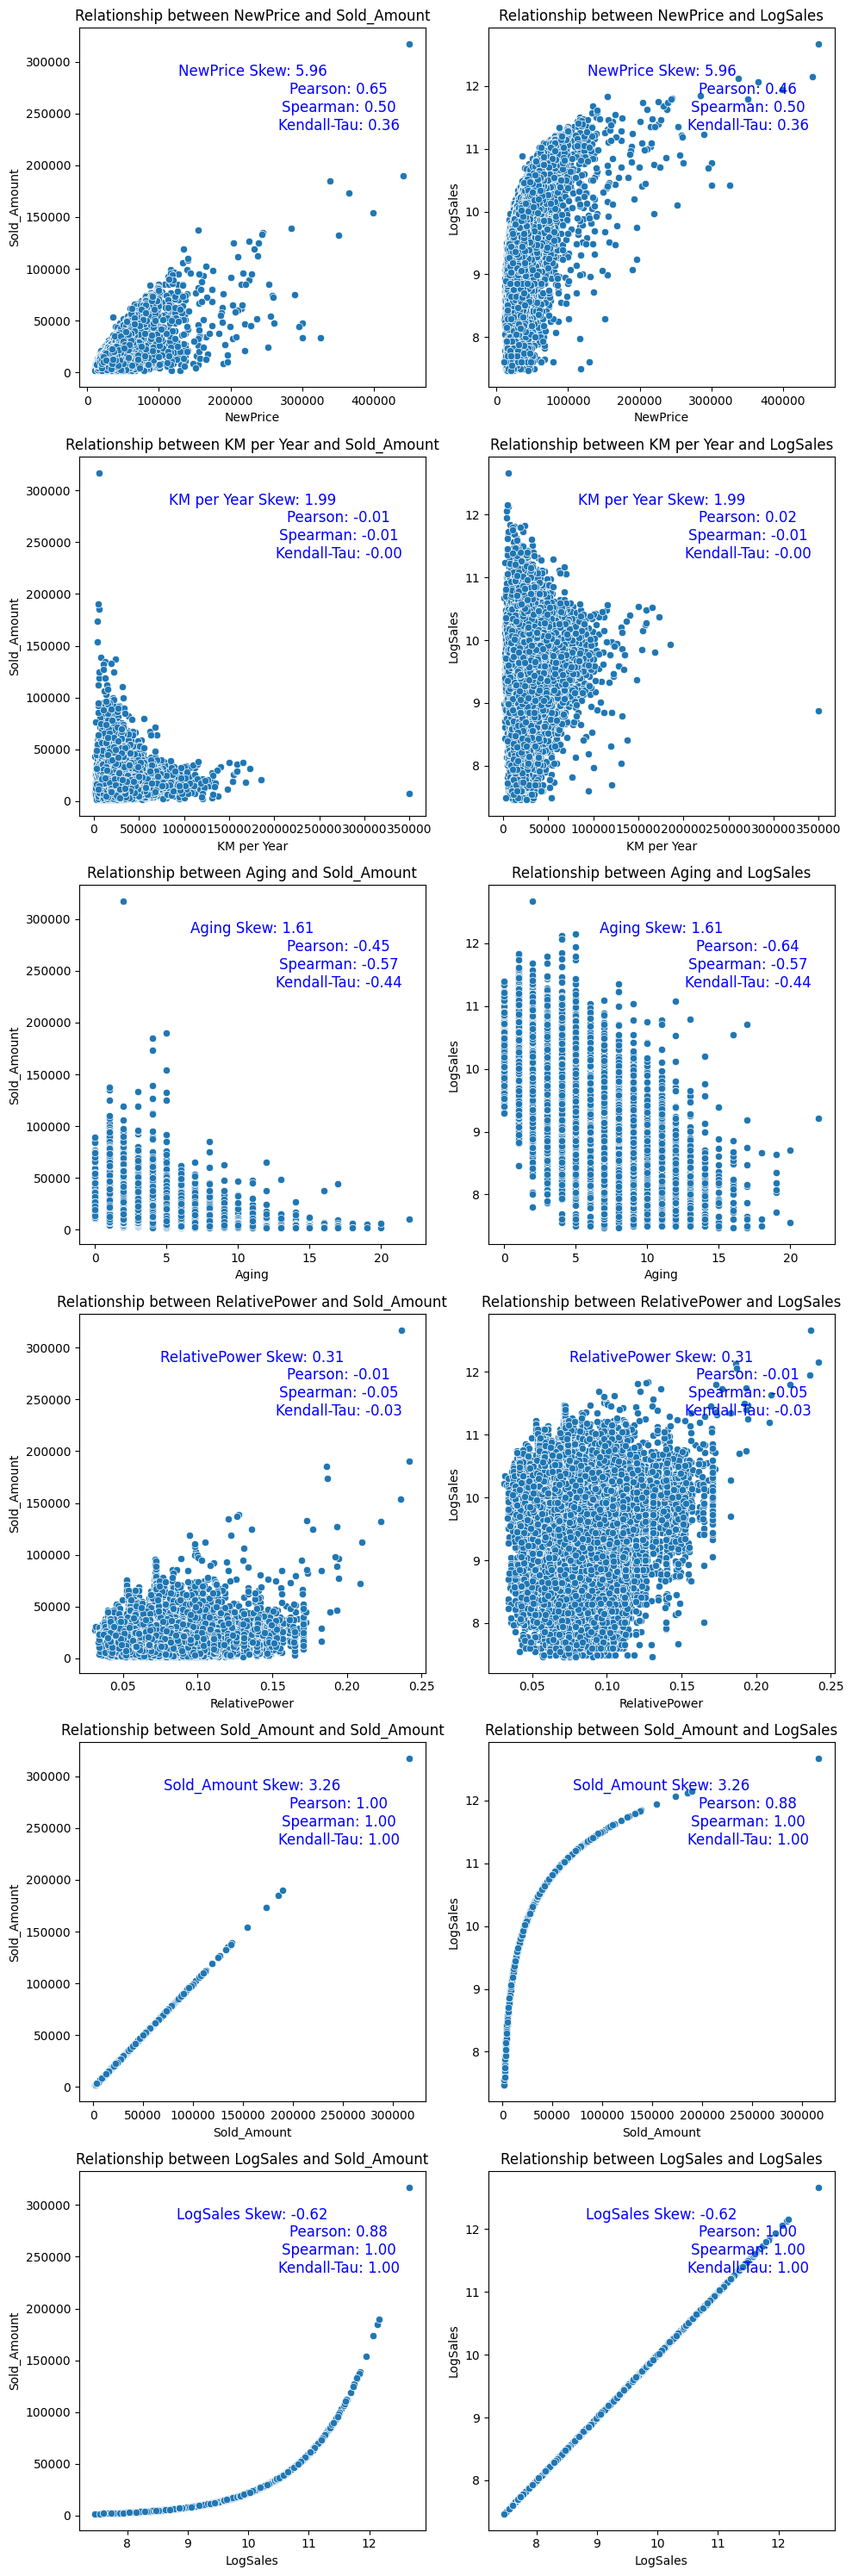

In [367]:
show_num_rls(feature_df[['NewPrice','KM per Year','Aging','RelativePower','Sold_Amount','LogSales']], 'Sold_Amount','LogSales')

Going to drop the Log Transformations we made for initial dataset, as we do not need to scale for our model.

In [270]:
feature_df.columns

Index(['MakeCode', 'BodyStyleDescription', 'VFactsClass',
       'FuelTypeDescription', 'EngineTypeDescription', 'GearNum', 'EngineSize',
       'Cylinders', 'Power', 'PowerRPMTo', 'Torque', 'TorqueRPMTo', 'DoorNum',
       'WheelBase', 'Height', 'Length', 'Width', 'KerbWeight', 'SeatCapacity',
       'YearGroup', 'Sold_Date', 'KM', 'AverageKM', 'GoodKM', 'SaleCategory',
       'Branch', 'BuildCountryOriginDescription', 'NewPrice', 'Sold_Amount',
       'ColorGroup', 'LogSales', 'LogKM', 'Aging', 'Age_Comp_Months_Fixed',
       'KM per Year', 'RelativePower', 'RelativeTorque'],
      dtype='object')

In [272]:
feature_df.drop(columns=['LogKM','LogSales'],inplace=True)

Im going to start by training my model on this Base Model. From here, I can look into the categorical variables that will help to enhance the performance of the model.

Let's load in the test dataset. I have already defined the preprocessing steps we did earlier in this notebook in model.py, and we will use the clean_data function to clean the data exactly as we did with the train data here, then apply it to a RandomForestRegressor.

In [ ]:
test_pth = "DatiumTest.rpt"
test_df = pd.read_table(test_pth)

/var/folders/zk/jyn4pz795tl33j_m94s1rzcr0000gn/T/ipykernel_76017/2569554405.py:4: DtypeWarning: Columns (27,91) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_table(test_pth)


In [401]:
drop_na_subset = ['Height','Length','Width','VFactsClass','TorqueRPMTo','Torque','WheelBase','PowerRPMTo','Power','Age_Comp_Months','Colour','SeatCapacity','Sold_Amount','KM','Sold_Date','GearNum','AverageKM','GoodKM','SaleCategory','Branch','BuildCountryOriginDescription','GoodRetail','PrivateMax','NewPrice']
test_df = test_df.dropna(subset=drop_na_subset).copy()

In [402]:
test_df['KerbWeight'] = test_df['KerbWeight'].fillna(test_df['KerbWeight'].mean())

In [403]:
test_df = test_df.loc[lambda x: x["Sold_Amount"] > 0]
test_df = test_df.loc[lambda x: x["Sold_Amount"] > np.exp(7.438383530044307)]
test_df = test_df.loc[lambda x: (x["KM"] > (10 ** 3.941779151214647)) & (x["KM"] < (10 ** 5.713650323816626))]
test_df['Aging'] = test_df.apply(lambda row: int(row['Sold_Date'][:4]) - row['YearGroup'],axis=1)
test_df['AgingMonths'] = test_df['Aging'].apply(lambda x: x*12)
test_df['Age_Comp_Months_Fixed'] = test_df.apply(lambda row: row['AgingMonths'] if row['Age_Comp_Months'] > row['AgingMonths'] else row['Age_Comp_Months'], axis=1)
test_df['KM per Year'] = test_df.apply(lambda row: row['KM']/(row['Age_Comp_Months_Fixed']/12) if row['Age_Comp_Months_Fixed'] > 0 else row['KM'], axis=1)
test_df['RelativePower'] = test_df['Power'] / test_df['KerbWeight']
test_df['RelativeTorque'] = test_df['Torque'] / test_df['KerbWeight']

In [404]:
test_df.shape

(10777, 136)

In [407]:
featureset1 = ['NewPrice','KM per Year','Aging','RelativePower']
X_train1 = feature_df[featureset1]
X_test1 = test_df[featureset1]
y_train1 = feature_df['Sold_Amount']
y_test1 = test_df['Sold_Amount']

In [416]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def transform_data(X, ordinal_features: List, ordinal_dict: dict) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include='number').columns
    categorical_features = [x for x in X.select_dtypes(include=['object']).columns if x not in ordinal_features]

    if ordinal_features == [] or ordinal_dict == {}:
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', FunctionTransformer(lambda x: x, validate=False), numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ]
        )
        return preprocessor
    else:
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', FunctionTransformer(lambda x: x, validate=False), numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
                ('ord', OrdinalEncoder(categories=ordinal_dict), ordinal_features)
            ]
        )
        return preprocessor

# Since we already have Train and Test data separately, we will pass it in explicity into the Regressor class
class RFRegressorPipeline():
    def __init__(self, X_train, y_train, X_test, y_test, random_state=42, ordinal_features = [], ordinal_dict = {}):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.random_state = random_state
        self.ordinal_features = ordinal_features
        self.ordinal_dict = ordinal_dict
    
    def run_and_train(self) -> Pipeline:
        preprocessor = transform_data(self.X_train, self.ordinal_features, self.ordinal_dict)
        model = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', RandomForestRegressor(random_state=self.random_state))])

        # Train
        model.fit(self.X_train, self.y_train)

        # Predict
        y_pred = model.predict(self.X_test)

        # Evaluate
        mae = mean_absolute_error(self.y_test, y_pred)
        rmse = root_mean_squared_error(self.y_test, y_pred)
        r2 = r2_score(self.y_test, y_pred)

        print(f"MAE: {mae}, RMSE: {rmse}, R2: {r2}")
        metrics = {"MAE":mae,"RMSE":rmse,"R2":r2}
        return model, metrics, y_pred

Not bad honestly, 0.83 R2 on our first try! Looks like we can predict the sales price fairly well from just our base car price depreciation model!

In [417]:
model_pipeline = RFRegressorPipeline(X_train1, y_train1, X_test1, y_test1)
model, metrics, predictions = model_pipeline.run_and_train()

MAE: 3113.6236583279206, RMSE: 4421.310297527579, R2: 0.8323975120354813


In [418]:
pd.DataFrame({'Sold_Amount':y_test1, 'Model 1 Prediction':predictions})

,Sold_Amount,Model 1 Prediction
0,18000.0,18228.5000
1,53250.0,49116.3000
2,11500.0,14439.8200
3,17500.0,19286.0000
4,17100.0,17084.2900
...,...,...
11483,16285.0,15327.8500
11484,41000.0,65451.5000
11485,16500.0,14454.0273
11486,10250.0,8299.4000


Let's save the feature_df and test_df for later reference

In [420]:
feature_df.to_csv('FeatureDF.csv',index=False)
test_df.to_csv('TestDF.csv',index=False)